### Projet informatique Monte Carlo : Deep Hedging

Nacer El Harti, Salma Zriaa

Ce notebook reprends les parties principales du code que nous avons exploité pour rédiger notre rapport. 

Dans tout ce notebook, on supposera les dynamiques des actifs suivant l'EDS de Black-Scholes. Le framework Black-Scholes permet d'obtenir des résultats analytiques et un benchmark de comparaison pour les modèles deep learning que nous avons mis en oeuvre. Dans tout le sujet, on considère la couverture d'un put vanille de payoff $$\phi(S_T) = (K-S_T)^+$$, dont la prime est connue avec la formule de Black-Scholes. 

L'objectif est à chaque fois de construire une stratégie de réplication dynamique en delta qui permette de reproduire le payoff de l'option.

Le PnL actualisé d'un trader qui se couvre en delta s'écrit:
$$\tilde{PnL}_{0,T} = P_0 - e^{-rT}\phi(S_T) + \sum_{i=0}^{n-1}q_i (\tilde{S}_{i+1}-\tilde{S}_i)$$

Avec $P_0$ le prix initial de l'option qu'on touche, $q_i$ le nombre d'actions servant à se couvrir dans le portefeuille du trader entre $t_i$ et $t_{i+1}$ pour $i \in \{0,...,n-1\}$ (stratégie en delta), et $\tilde{S}$ est le prix actualisé de l'actif (qui suit la dynamique de Black-Scholes). Si la stratégie réplique parfaitement le payoff, alors $$\tilde{PnL}_{0,T} = 0 $$.

Entre $t_i$ et $t_{i+1}$, un trader se doit d'ajuster sa position en delta sur l'actif qu'il possède pour se couvrir. Ainsi à chaque instant $t_k$ le portefeuille de couverture s'écrit : 

$$V_{k} = V_{k-1} - (q_i - q_{i-1})\tilde{S}_{i}$$

Dans un premier temps, on calcule $q_i$ comme étant les delta de l'option par Black-Scholes pour tester l'efficience de cette stratégie.  Dans la suite, on remplace la stratégie analytique par une stratégie paramétrique apprise : $$q_i = q_{\theta}(t_i,S_{t_i})$$.

L’apprentissage consiste à choisir $\theta$ pour contrôler le risque du PnL.



In [ ]:
# Partie fonctions essentielles

import math
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme() 
from numpy.random import default_rng
rng = default_rng()

from scipy.stats import norm

def monte_carlo(sample, proba = 0.95): #calcul des statistiques sur résultats finaux
    mean = np.mean(sample).item()
    var = np.var(sample, ddof=1).item()
    alpha = 1 - proba 
    quantile = stats.norm.ppf(1 - alpha/2).item()  # fonction quantile 
    ci_size = quantile * math.sqrt(var / sample.size)
    result = { 'mean': mean, 'var': var, 
               'lower': mean - ci_size, 
               'upper': mean + ci_size }
    return result

def d1(spot, t, r, sigma, strike): #calcul du d1 formule BS
    return (np.log(spot / strike) + t * (r + 0.5*sigma**2)) / (sigma * np.sqrt(t))

def d2(spot, t, r, sigma, strike): #calcul du d2 formule BS
    return d1(spot, t, r, sigma, strike) - sigma * np.sqrt(t)

def price_call_BS(spot, t, r, sigma, strike): #calcul du prix BS call
    d1_ = d1(spot, t, r, sigma, strike)
    d2_ = d2(spot, t, r, sigma, strike)
    return spot * norm.cdf(d1_) - strike * np.exp(-r * t) * norm.cdf(d2_)

def price_put_BS(spot,t,r,sigma,strike) : #calcul du prix BS put en utilisant la parité C-P
    d1_ = d1(spot, t, r, sigma, strike)
    d2_ = d2(spot, t, r, sigma, strike)
    return price_call_BS(spot, t,r,sigma,strike)-spot+strike * np.exp(-r*t)

def dprice_call_BS(spot, t, r, sigma, strike): #calcul du delta call
    return norm.cdf(d1(spot, t, r, sigma, strike))

def dprice_put_BS(spot, t, r, sigma, strike): #calcul du delta put (delta_call - 1)
    return norm.cdf(d1(spot, t, r, sigma, strike))-1

import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

class NeuralNetwork(nn.Module) : #architecture à 2 couches
    def __init__(self,input_size,hidden_size,output_size) : 
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size,hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size,hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size,output_size)
        )
    def forward(self,x) : 
        out = self.linear_relu_stack(x)
        return out
    
#Paramètres
r = 0.1
sigma = 0.25
S0 = 100.
K = 100.
N, T = 10, 1

#fonctions
def simulation_brownien(n, T, M):
    B = np.zeros((M, n+1))
    B[:, 1:] = np.cumsum(np.sqrt(T/n) * np.random.standard_normal(size=(M, n)), axis=1)
    return B

def simulation_actif(n, T, M, S0, sigma, r):
    S = np.zeros((M, n+1))
    S[:, 0] = S0
    brownian = simulation_brownien(n, T, M)
    dt = T / n
    for i in range(1, n+1):
        S[:, i] = S[:, i-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * (brownian[:, i] - brownian[:, i-1]))
    return S

def payoff_call(S, K):
    return np.maximum(0.0, S - K)

def payoff_put(S,K) : 
    return np.maximum(0,K-S)

Using cpu device


### Cas sans transaction costs : comparaison NN vs BS

Dans un premier temps, comparons les deux approches en omettant les coûts de transactions. En effet, les hypothèses de BS exluent les coûts de transactions. Ce premier volet nous aide à nous assurer du bon fonctionnement de l'approche par réseau de neurones


Training NN hedge with H = 16
H=16 | Epoch 1/10 - Train MSE: 13.923028
H=16 | Epoch 2/10 - Train MSE: 6.207370
H=16 | Epoch 3/10 - Train MSE: 5.733926
H=16 | Epoch 4/10 - Train MSE: 5.613769
H=16 | Epoch 5/10 - Train MSE: 5.571236
H=16 | Epoch 6/10 - Train MSE: 5.556192
H=16 | Epoch 7/10 - Train MSE: 5.544750
H=16 | Epoch 8/10 - Train MSE: 5.537733
H=16 | Epoch 9/10 - Train MSE: 5.534696
H=16 | Epoch 10/10 - Train MSE: 5.530985

Training NN hedge with H = 32
H=32 | Epoch 1/10 - Train MSE: 10.009522
H=32 | Epoch 2/10 - Train MSE: 5.944412
H=32 | Epoch 3/10 - Train MSE: 5.723865
H=32 | Epoch 4/10 - Train MSE: 5.612919
H=32 | Epoch 5/10 - Train MSE: 5.564814
H=32 | Epoch 6/10 - Train MSE: 5.538334
H=32 | Epoch 7/10 - Train MSE: 5.526534
H=32 | Epoch 8/10 - Train MSE: 5.521751
H=32 | Epoch 9/10 - Train MSE: 5.513457
H=32 | Epoch 10/10 - Train MSE: 5.513662

Training NN hedge with H = 64
H=64 | Epoch 1/10 - Train MSE: 6.403159
H=64 | Epoch 2/10 - Train MSE: 5.500218
H=64 | Epoch 3/10 - Tra

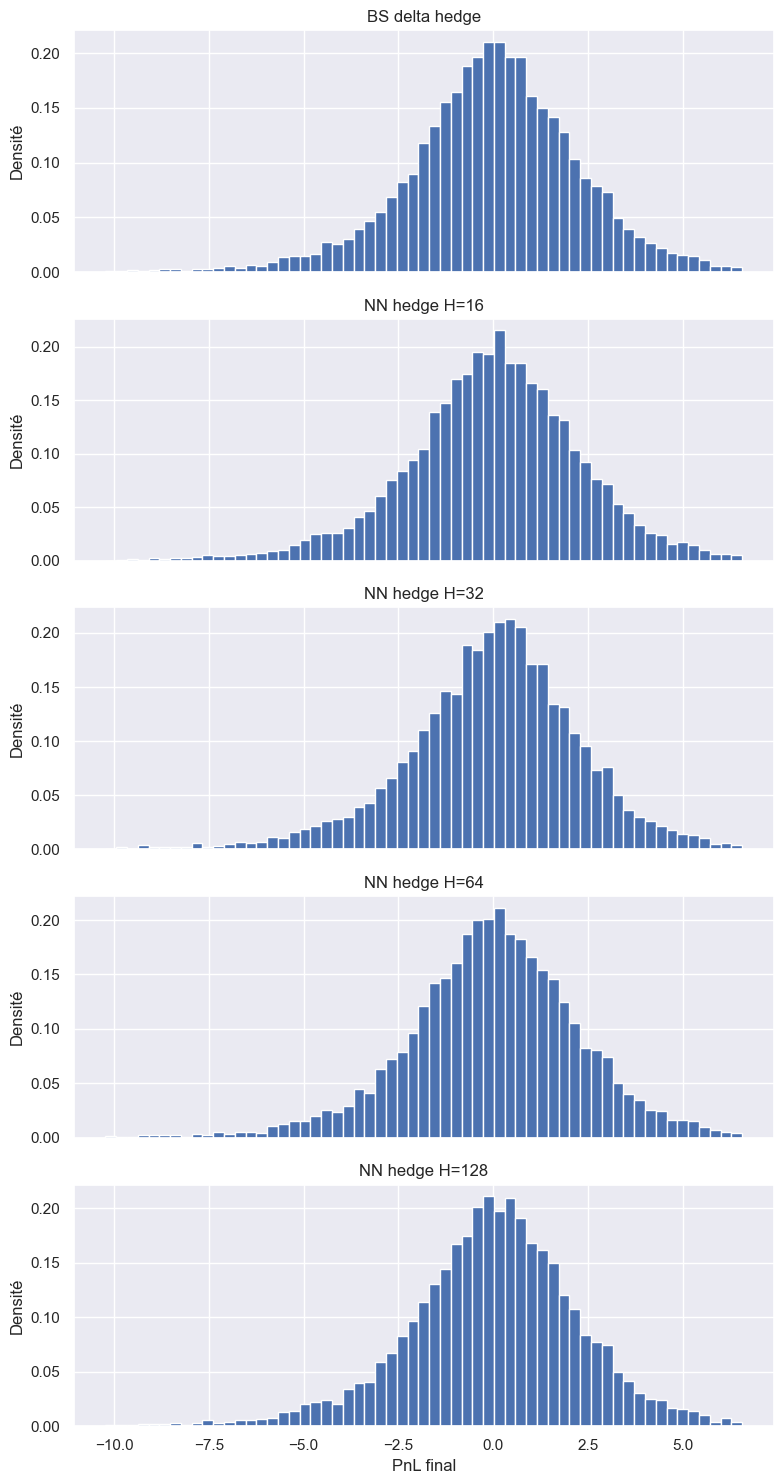

In [108]:
import pandas as pd
hidden_sizes = [16, 32, 64, 128] #nombre de couches cachées

all_train_losses = {}
all_results = []
all_pnls = {}

# train data

M = 10**6 #nombre de simulations pour le train set
M_test = 10**4 #nombre de simulation pour le test set, indépendantes du train
batch_size = 1000
n_epochs = 10
learning_rate = 1e-3


sample_S_raw = simulation_actif(N, T, M, S0, sigma, r) #simulation pour le train

times = np.arange(N + 1) * T / N

#données de normalisation
moyenne = S0 * np.exp(r * times)
ecart_type = S0 * np.exp(r * times) * np.sqrt(np.exp(sigma**2 * times) - 1)
ecart_type[0] = 1.0

sample_S_norm = (sample_S_raw - moyenne) / ecart_type #données normalisées

S_act = sample_S_raw * np.exp(-r * times)
dS_np = np.diff(S_act, axis=1)

tau_grid = (T - times[:-1]) / T

data_np = np.stack([
    sample_S_norm[:, :-1],
    np.repeat(tau_grid.reshape(1, -1), M, axis=0)
], axis=2) 

phi_np = payoff_put(sample_S_raw[:, -1], K) * np.exp(-r * T)

data = torch.from_numpy(data_np).float().to(device)
dS = torch.from_numpy(dS_np).float().to(device)
phi = torch.from_numpy(phi_np).float().to(device)

P0_val = float(price_put_BS(S0, T, r, sigma, K))
P0 = torch.tensor(P0_val, dtype=torch.float32, device=device)

size_tot = data.shape[0]
nb_batch = size_tot // batch_size

# test data

np.random.seed(42)
sample_S_test = simulation_actif(N, T, M_test, S0, sigma, r)

sample_norm_test = (sample_S_test - moyenne) / ecart_type

tau_grid_test = (T - np.arange(N) * T / N) / T
tau_mat = np.repeat(tau_grid_test.reshape(1, -1), M_test, axis=0)

X_test = np.stack([sample_norm_test[:, :-1], tau_mat], axis=2)
X_test_torch = torch.from_numpy(X_test).float().to(device)

sample_S_test_disc = sample_S_test * np.exp(-r * times)
dS_test = np.diff(sample_S_test_disc, axis=1)

payoff_disc = np.exp(-r * T) * np.maximum(K - sample_S_test[:, -1], 0)

# BS DELTA HEDGE test set

sample_bs = sample_S_test.T

delta_bs = np.zeros((N, M_test))

for n in range(N):
    tau_n = T - n * T / N
    delta_bs[n] = dprice_put_BS(sample_bs[n], tau_n, r, sigma, K)

delta_bs = delta_bs.T

pnl_bs = (
    P0_val
    - payoff_disc
    + np.sum(delta_bs * dS_test, axis=1)
)

all_pnls["BS delta hedge"] = pnl_bs

def compute_metrics(pnl, name):
    return {
        "Model": name,
        "Bias": np.mean(pnl),
        "Std": np.std(pnl),
        "Q01": np.quantile(pnl, 0.01),
        "Q99": np.quantile(pnl, 0.99),
        "CVaR_95_left": pnl[pnl <= np.quantile(pnl, 0.05)].mean(),
        "CVaR_99_left": pnl[pnl <= np.quantile(pnl, 0.01)].mean()
    }

all_results.append(compute_metrics(pnl_bs, "BS delta hedge"))


# train et test pour chaque architecture


for H in hidden_sizes:

    print(f"\n==============================")
    print(f"Training NN hedge with H = {H}")
    print(f"==============================")

    f = NeuralNetwork(input_size=2, hidden_size=H, output_size=1).to(device)
    optimizer = torch.optim.Adam(f.parameters(), lr=learning_rate)

    train_losses = []

    for epoch in range(n_epochs):

        perm = torch.randperm(size_tot, device=device)
        epoch_loss = 0.0

        for j in range(nb_batch):

            idx_batch = perm[j * batch_size:(j + 1) * batch_size]

            X_batch = data[idx_batch]
            dS_batch = dS[idx_batch]
            phi_batch = phi[idx_batch]

            q = f(X_batch).squeeze(-1)

            delta_pnl = (q * dS_batch).sum(dim=1)
            pnl = P0 - phi_batch + delta_pnl

            loss = torch.mean(pnl**2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= nb_batch
        train_losses.append(epoch_loss)

        print(f"H={H} | Epoch {epoch+1}/{n_epochs} - Train MSE: {epoch_loss:.6f}")

    all_train_losses[H] = train_losses

    # =========================
    # TEST NN
    # =========================

    f.eval()
    with torch.no_grad():
        delta_nn = f(X_test_torch).squeeze(-1).cpu().numpy()

    pnl_nn = (
        P0_val
        - payoff_disc
        + np.sum(delta_nn * dS_test, axis=1)
    )

    model_name = f"NN hedge H={H}"

    all_pnls[model_name] = pnl_nn
    all_results.append(compute_metrics(pnl_nn, model_name))

results = pd.DataFrame(all_results)
print(results.round(6))

# Histogrammes séparés pour chaque modèle

all_names = list(all_pnls.keys())
n_models = len(all_names)

fig, axes = plt.subplots(n_models, 1, figsize=(8, 3 * n_models), sharex=True)

if n_models == 1:
    axes = [axes]

# bornes communes pour comparer correctement
all_pnl_values = np.concatenate(list(all_pnls.values()))
bins = np.linspace(
    np.quantile(all_pnl_values, 0.001),
    np.quantile(all_pnl_values, 0.999),
    60
)

for ax, name in zip(axes, all_names):
    pnl = all_pnls[name]
    
    ax.hist(pnl, bins=bins, density=True)
    ax.set_title(name)
    ax.set_ylabel("Densité")

axes[-1].set_xlabel("PnL final")

plt.tight_layout()
plt.show()


### Coût de transactions

Maintenant, considérons le modèles avec coûts de transactions.


===== Training H = 16 =====
H=16 | Epoch 1/10 | Train MSE: 34.770531
H=16 | Epoch 2/10 | Train MSE: 32.664409
H=16 | Epoch 3/10 | Train MSE: 32.393946
H=16 | Epoch 4/10 | Train MSE: 32.236715
H=16 | Epoch 5/10 | Train MSE: 32.096626
H=16 | Epoch 6/10 | Train MSE: 31.913894
H=16 | Epoch 7/10 | Train MSE: 31.822851
H=16 | Epoch 8/10 | Train MSE: 31.805047
H=16 | Epoch 9/10 | Train MSE: 31.800331
H=16 | Epoch 10/10 | Train MSE: 31.779466

===== Training H = 32 =====
H=32 | Epoch 1/10 | Train MSE: 38.021834
H=32 | Epoch 2/10 | Train MSE: 32.221193
H=32 | Epoch 3/10 | Train MSE: 31.981112
H=32 | Epoch 4/10 | Train MSE: 31.914354
H=32 | Epoch 5/10 | Train MSE: 31.872773
H=32 | Epoch 6/10 | Train MSE: 31.847943
H=32 | Epoch 7/10 | Train MSE: 31.834781
H=32 | Epoch 8/10 | Train MSE: 31.812733
H=32 | Epoch 9/10 | Train MSE: 31.809692
H=32 | Epoch 10/10 | Train MSE: 31.798462

===== Training H = 64 =====
H=64 | Epoch 1/10 | Train MSE: 35.636354
H=64 | Epoch 2/10 | Train MSE: 31.914526
H=64 | Ep

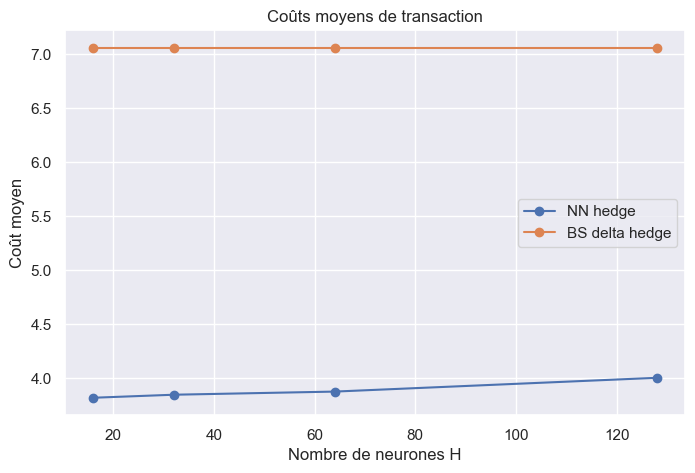

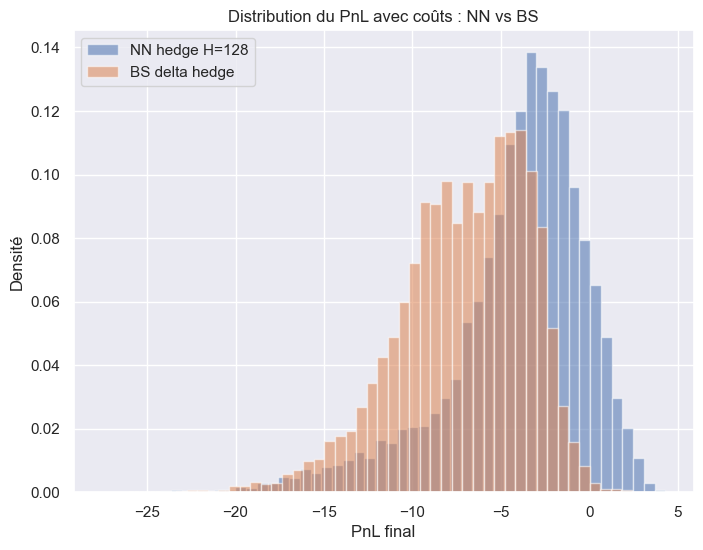

In [110]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

H_range = [16, 32, 64,128]
eps = 5*1e-2 #le facteur proportionnel dans la formule des coûts
M_test = 10**4

results = []
pnl_by_H = {}
pnl_bs_by_H = {}

for H in H_range:

    print(f"\n===== Training H = {H} =====")

    sample_S_raw = simulation_actif(N, T, M, S0, sigma, r)

    times = np.arange(N + 1) * T / N
    moyenne = S0 * np.exp(r * times)
    ecart_type = S0 * np.exp(r * times) * np.sqrt(np.exp(sigma**2 * times) - 1)
    ecart_type[0] = 1.0

    sample_S_norm = (sample_S_raw - moyenne) / ecart_type

    S_act = sample_S_raw * np.exp(-r * times)
    dS = np.diff(S_act, axis=1)

    tau_grid = (T - times[:-1]) / T

    data = np.stack([
        sample_S_norm[:, :-1],
        np.repeat(tau_grid.reshape(1, -1), M, axis=0)
    ], axis=2)

    phi = payoff_put(sample_S_raw[:, -1], K) * np.exp(-r * T)

    data = torch.from_numpy(data).float().to(device)
    dS = torch.from_numpy(dS).float().to(device)
    phi = torch.from_numpy(phi).float().to(device)
    S_act_torch = torch.from_numpy(S_act).float().to(device)

    P0_val = float(price_put_BS(S0, T, r, sigma, K))
    P0 = torch.tensor(P0_val, dtype=torch.float32, device=device)

    # modèle

    f = NeuralNetwork(input_size=2, hidden_size=H, output_size=1).to(device)
    optimizer = torch.optim.Adam(f.parameters(), lr=learning_rate)

    size_tot = data.shape[0]
    nb_batch = size_tot // batch_size

    # phase d'entraînement

    for epoch in range(n_epochs):

        perm = torch.randperm(size_tot, device=device)
        epoch_loss = 0.0

        for j in range(nb_batch):

            idx_batch = perm[j * batch_size:(j + 1) * batch_size]

            X_batch = data[idx_batch]
            dS_batch = dS[idx_batch]
            phi_batch = phi[idx_batch]
            S_batch = S_act_torch[idx_batch]

            q = f(X_batch).squeeze(-1)

            delta_pnl = (q * dS_batch).sum(dim=1)

            # partie coûts de transaction
            q_prev = torch.cat(
                [torch.zeros(q.shape[0], 1, device=device), q],
                dim=1
            )

            q_next = torch.cat(
                [q, torch.zeros(q.shape[0], 1, device=device)],
                dim=1
            )

            costs = eps * torch.sum(
                S_batch * torch.abs(q_next - q_prev),
                dim=1
            )

            pnl = P0 - phi_batch + delta_pnl - costs #pnl final

            loss = torch.mean(pnl**2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= nb_batch

        print(f"H={H} | Epoch {epoch+1}/{n_epochs} | Train MSE: {epoch_loss:.6f}")


    np.random.seed(42)
    sample_S_test = simulation_actif(N, T, M_test, S0, sigma, r)

    times = np.arange(N + 1) * T / N
    moyenne = S0 * np.exp(r * times)
    ecart_type = S0 * np.exp(r * times) * np.sqrt(np.exp(sigma**2 * times) - 1)
    ecart_type[0] = 1.0

    sample_norm_test = (sample_S_test - moyenne) / ecart_type

    tau_grid = (T - np.arange(N) * T / N) / T
    tau_mat = np.repeat(tau_grid.reshape(1, -1), M_test, axis=0)

    X_test = np.stack([sample_norm_test[:, :-1], tau_mat], axis=2)
    X_test_torch = torch.from_numpy(X_test).float().to(device)

    sample_S_test_disc = sample_S_test * np.exp(-r * times)
    dS_test = np.diff(sample_S_test_disc, axis=1)

    payoff_disc = np.exp(-r * T) * np.maximum(K - sample_S_test[:, -1], 0)

    f.eval()
    with torch.no_grad():
        q_nn = f(X_test_torch).squeeze(-1).cpu().numpy()

    # intégration des coûts de transaction

    q_prev_nn = np.concatenate([np.zeros((M_test, 1)), q_nn], axis=1)
    q_next_nn = np.concatenate([q_nn, np.zeros((M_test, 1))], axis=1)

    costs_nn = eps * np.sum(
        sample_S_test_disc * np.abs(q_next_nn - q_prev_nn),
        axis=1
    )

    delta_pnl_nn = np.sum(q_nn * dS_test, axis=1)

    pnl_nn = (
        P0_val
        - payoff_disc
        + delta_pnl_nn
        - costs_nn
    )

    pnl_by_H[H] = pnl_nn


    sample_bs = sample_S_test.T

    delta_bs = np.zeros((N, M_test))
    for n in range(N):
        tau_n = T - n * T / N
        delta_bs[n] = dprice_put_BS(sample_bs[n], tau_n, r, sigma, K)

    q_bs = delta_bs.T

    q_prev_bs = np.concatenate([np.zeros((M_test, 1)), q_bs], axis=1)
    q_next_bs = np.concatenate([q_bs, np.zeros((M_test, 1))], axis=1)

    costs_bs = eps * np.sum(
        sample_S_test_disc * np.abs(q_next_bs - q_prev_bs),
        axis=1
    )

    delta_pnl_bs = np.sum(q_bs * dS_test, axis=1)

    pnl_bs = (
        P0_val
        - payoff_disc
        + delta_pnl_bs
        - costs_bs
    )
    pnl_bs_by_H[H] = pnl_bs

    def compute_metrics(pnl, costs, q_prev, q_next, name, H):
        q01 = np.quantile(pnl, 0.01)
        q99 = np.quantile(pnl, 0.99)

        return {
            "Model": name,
            "H": H,
            "Bias": np.mean(pnl),
            "Std": np.std(pnl),
            "Q01": q01,
            "Q99": q99,
            "CVaR_99_left": pnl[pnl <= q01].mean(),
            "Mean_cost": np.mean(costs),
            "Mean_turnover": np.mean(np.sum(np.abs(q_next - q_prev), axis=1))
        }

    results.append(compute_metrics(pnl_nn, costs_nn, q_prev_nn, q_next_nn, "NN hedge with costs", H))
    results.append(compute_metrics(pnl_bs, costs_bs, q_prev_bs, q_next_bs, "BS delta hedge with costs", H))

results_df = pd.DataFrame(results)
print(results_df.round(6))


nn_df = results_df[results_df["Model"] == "NN hedge with costs"]
bs_df = results_df[results_df["Model"] == "BS delta hedge with costs"]


fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(nn_df["H"], nn_df["Mean_cost"], marker="o", label="NN hedge")
ax.plot(bs_df["H"], bs_df["Mean_cost"], marker="o", label="BS delta hedge")

ax.set_xlabel("Nombre de neurones H")
ax.set_ylabel("Coût moyen")
ax.set_title("Coûts moyens de transaction")
ax.legend()
plt.show()

best_H = 128

fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(
    pnl_by_H[best_H],
    bins=50,
    density=True,
    alpha=0.55,
    label=f"NN hedge H={best_H}"
)

ax.hist(
    pnl_bs_by_H[best_H],
    bins=50,
    density=True,
    alpha=0.55,
    label="BS delta hedge"
)

ax.set_xlabel("PnL final")
ax.set_ylabel("Densité")
ax.set_title("Distribution du PnL avec coûts : NN vs BS")
ax.legend()
plt.show()

Essayons maintenant de faire varier le paramètre proportionnel pour mesurer l'impact du lambda sur la stratégie adoptée et sur le PnL final


Lambda = 0.001

===== Training lambda=0.001, H=16 =====
lambda=0.001 | H=16 | Epoch 1/10 | Train MSE=11.935205
lambda=0.001 | H=16 | Epoch 2/10 | Train MSE=6.255750
lambda=0.001 | H=16 | Epoch 3/10 | Train MSE=5.929218
lambda=0.001 | H=16 | Epoch 4/10 | Train MSE=5.780283
lambda=0.001 | H=16 | Epoch 5/10 | Train MSE=5.706892
lambda=0.001 | H=16 | Epoch 6/10 | Train MSE=5.676808
lambda=0.001 | H=16 | Epoch 7/10 | Train MSE=5.659043
lambda=0.001 | H=16 | Epoch 8/10 | Train MSE=5.649070
lambda=0.001 | H=16 | Epoch 9/10 | Train MSE=5.641006
lambda=0.001 | H=16 | Epoch 10/10 | Train MSE=5.635368

===== Training lambda=0.001, H=32 =====
lambda=0.001 | H=32 | Epoch 1/10 | Train MSE=15.580376
lambda=0.001 | H=32 | Epoch 2/10 | Train MSE=6.056905
lambda=0.001 | H=32 | Epoch 3/10 | Train MSE=5.741662
lambda=0.001 | H=32 | Epoch 4/10 | Train MSE=5.662217
lambda=0.001 | H=32 | Epoch 5/10 | Train MSE=5.644585
lambda=0.001 | H=32 | Epoch 6/10 | Train MSE=5.633723
lambda=0.001 | H=32 | Epoch 7/10 | 

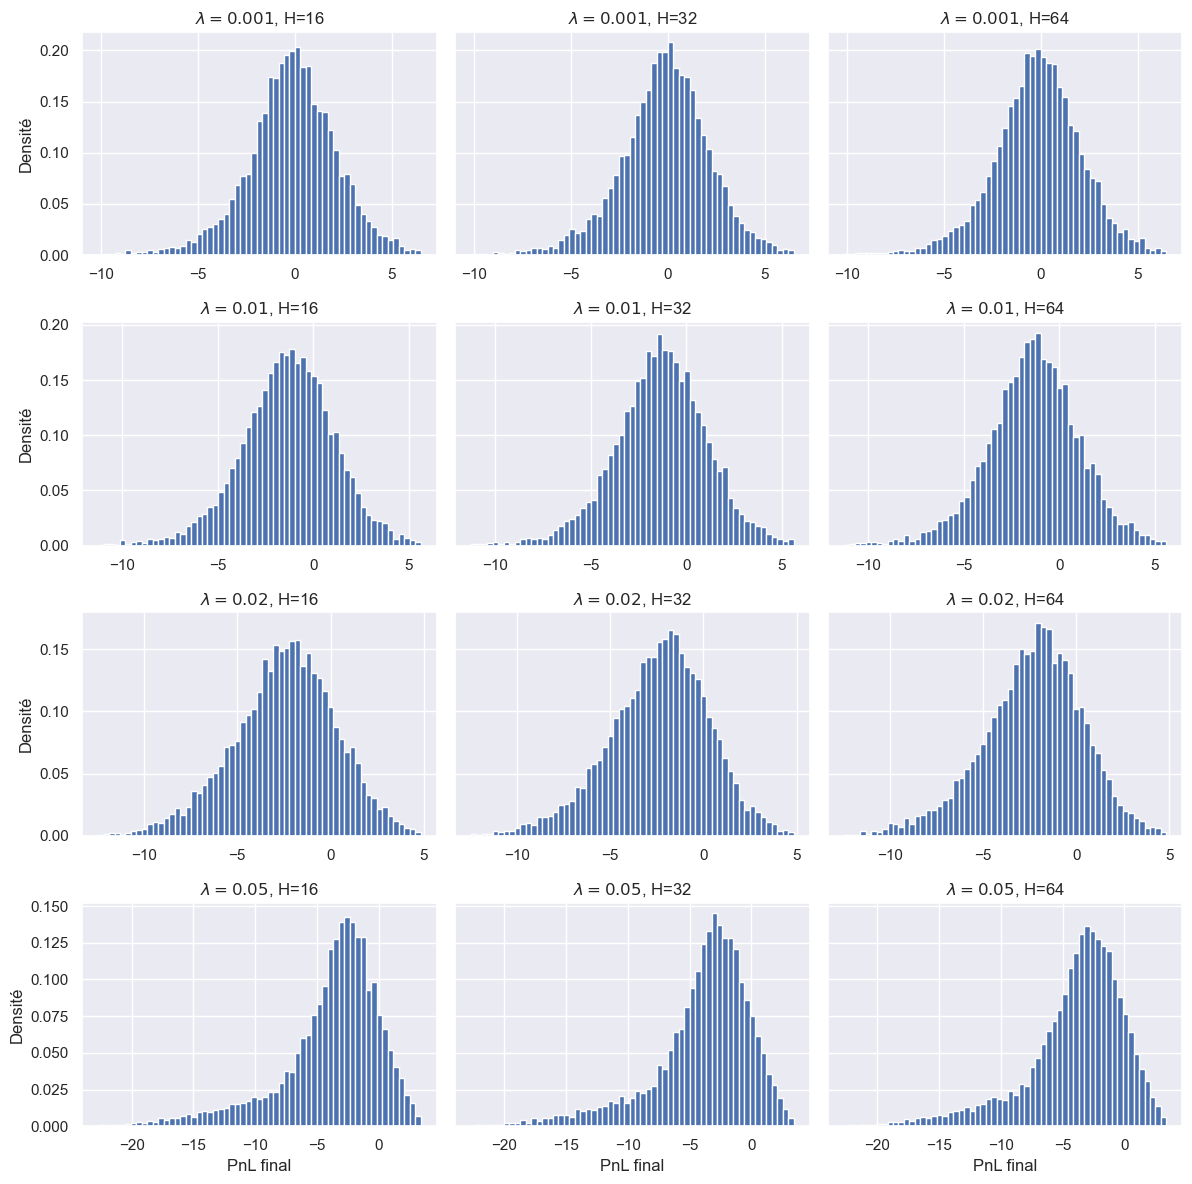

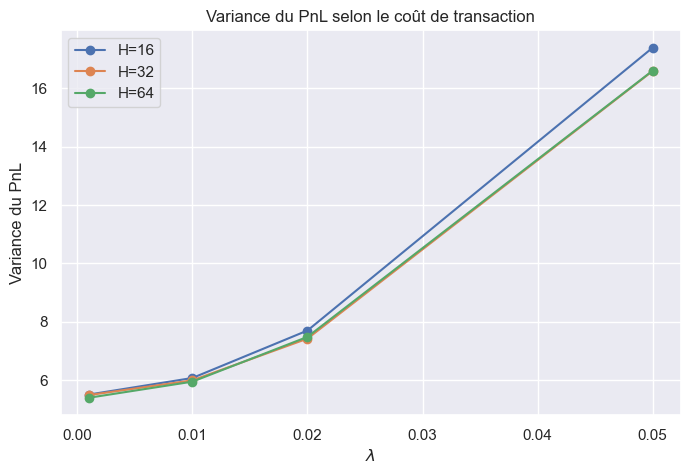

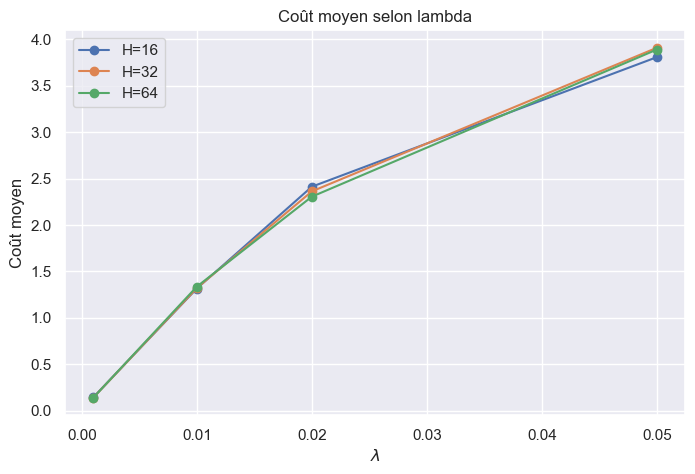

In [111]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import math


H_range = [16, 32, 64]
lambda_range = [1e-3,1e-2, 2e-2, 5e-2] #range de lambda à tester

M_test = 10**4

results = []
pnl_by_lambda_H = {}
pnl_bs_by_lambda = {}

#données test

np.random.seed(42)
sample_S_test = simulation_actif(N, T, M_test, S0, sigma, r)

times = np.arange(N + 1) * T / N

moyenne = S0 * np.exp(r * times)
ecart_type = S0 * np.exp(r * times) * np.sqrt(np.exp(sigma**2 * times) - 1)
ecart_type[0] = 1.0

sample_norm_test = (sample_S_test - moyenne) / ecart_type

tau_grid = (T - times[:-1]) / T
tau_mat_test = np.repeat(tau_grid.reshape(1, -1), M_test, axis=0)

X_test = np.stack([sample_norm_test[:, :-1], tau_mat_test], axis=2)
X_test_torch = torch.from_numpy(X_test).float().to(device)

sample_S_test_disc = sample_S_test * np.exp(-r * times)
dS_test = np.diff(sample_S_test_disc, axis=1)

payoff_disc = np.exp(-r * T) * np.maximum(K - sample_S_test[:, -1], 0)

P0_val = float(price_put_BS(S0, T, r, sigma, K))
P0 = torch.tensor(P0_val, dtype=torch.float32, device=device)

# calcul du delta hedging par BS

sample_bs = sample_S_test.T
delta_bs = np.zeros((N, M_test))

for n in range(N):
    tau_n = T - n * T / N
    delta_bs[n] = dprice_put_BS(sample_bs[n], tau_n, r, sigma, K)

q_bs = delta_bs.T

q_prev_bs = np.concatenate([np.zeros((M_test, 1)), q_bs], axis=1)
q_next_bs = np.concatenate([q_bs, np.zeros((M_test, 1))], axis=1)

delta_pnl_bs = np.sum(q_bs * dS_test, axis=1)


# train avec des lambda différents

for lam in lambda_range:

    print("\n====================================")
    print(f"Lambda = {lam}")
    print("====================================")

    costs_bs = lam * np.sum(
        sample_S_test_disc * np.abs(q_next_bs - q_prev_bs),
        axis=1
    )

    pnl_bs = (
        P0_val
        - payoff_disc
        + delta_pnl_bs
        - costs_bs
    )

    pnl_bs_by_lambda[lam] = pnl_bs

    for H in H_range:

        print(f"\n===== Training lambda={lam}, H={H} =====")


        sample_S_raw = simulation_actif(N, T, M, S0, sigma, r)

        sample_S_norm = (sample_S_raw - moyenne) / ecart_type

        S_act = sample_S_raw * np.exp(-r * times)
        dS_np = np.diff(S_act, axis=1)

        data_np = np.stack([
            sample_S_norm[:, :-1],
            np.repeat(tau_grid.reshape(1, -1), M, axis=0)
        ], axis=2)

        phi_np = payoff_put(sample_S_raw[:, -1], K) * np.exp(-r * T)

        data = torch.from_numpy(data_np).float().to(device)
        dS = torch.from_numpy(dS_np).float().to(device)
        phi = torch.from_numpy(phi_np).float().to(device)
        S_act_torch = torch.from_numpy(S_act).float().to(device)


        f = NeuralNetwork(input_size=2, hidden_size=H, output_size=1).to(device)
        optimizer = torch.optim.Adam(f.parameters(), lr=learning_rate)

        size_tot = data.shape[0]
        nb_batch = size_tot // batch_size


        for epoch in range(n_epochs):

            perm = torch.randperm(size_tot, device=device)
            epoch_loss = 0.0

            for j in range(nb_batch):

                idx_batch = perm[j * batch_size:(j + 1) * batch_size]

                X_batch = data[idx_batch]
                dS_batch = dS[idx_batch]
                phi_batch = phi[idx_batch]
                S_batch = S_act_torch[idx_batch]

                q = f(X_batch).squeeze(-1)

                delta_pnl = (q * dS_batch).sum(dim=1)

                q_prev = torch.cat(
                    [torch.zeros(q.shape[0], 1, device=device), q],
                    dim=1
                )

                q_next = torch.cat(
                    [q, torch.zeros(q.shape[0], 1, device=device)],
                    dim=1
                )

                costs = lam * torch.sum(
                    S_batch * torch.abs(q_next - q_prev),
                    dim=1
                )

                pnl = P0 - phi_batch + delta_pnl - costs

                loss = torch.mean(pnl**2)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()

            epoch_loss /= nb_batch

            print(
                f"lambda={lam} | H={H} | "
                f"Epoch {epoch+1}/{n_epochs} | Train MSE={epoch_loss:.6f}"
            )


        f.eval()
        with torch.no_grad():
            q_nn = f(X_test_torch).squeeze(-1).cpu().numpy()

        q_prev_nn = np.concatenate([np.zeros((M_test, 1)), q_nn], axis=1)
        q_next_nn = np.concatenate([q_nn, np.zeros((M_test, 1))], axis=1)

        costs_nn = lam * np.sum(
            sample_S_test_disc * np.abs(q_next_nn - q_prev_nn),
            axis=1
        )

        delta_pnl_nn = np.sum(q_nn * dS_test, axis=1)

        pnl_nn = (
            P0_val
            - payoff_disc
            + delta_pnl_nn
            - costs_nn
        )

        pnl_by_lambda_H[(lam, H)] = pnl_nn

        q01 = np.quantile(pnl_nn, 0.01)
        q99 = np.quantile(pnl_nn, 0.99)

        results.append({
            "lambda": lam,
            "H": H,
            "Mean": np.mean(pnl_nn),
            "Variance": np.var(pnl_nn),
            "Std": np.std(pnl_nn),
            "Q01": q01,
            "Q99": q99,
            "CVaR_99_left": pnl_nn[pnl_nn <= q01].mean(),
            "Mean_cost": np.mean(costs_nn),
            "Mean_turnover": np.mean(np.sum(np.abs(q_next_nn - q_prev_nn), axis=1))
        })

results_df = pd.DataFrame(results)

# plot distribution par lambda par largeur de couche H

n_rows = len(lambda_range)
n_cols = len(H_range)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3 * n_rows),
    sharex="row",
    sharey="row"
)

for i, lam in enumerate(lambda_range):

    all_pnl_lam = np.concatenate([
        pnl_by_lambda_H[(lam, H)] for H in H_range
    ])

    bins = np.linspace(
        np.quantile(all_pnl_lam, 0.001),
        np.quantile(all_pnl_lam, 0.999),
        60
    )

    for j, H in enumerate(H_range):

        ax = axes[i, j]

        ax.hist(
            pnl_by_lambda_H[(lam, H)],
            bins=bins,
            density=True
        )

        ax.set_title(rf"$\lambda={lam}$, H={H}")

        if j == 0:
            ax.set_ylabel("Densité")

        if i == n_rows - 1:
            ax.set_xlabel("PnL final")

plt.tight_layout()
plt.show()

# variance selon lambda


fig, ax = plt.subplots(figsize=(8, 5))

for H in H_range:
    df_H = results_df[results_df["H"] == H].sort_values("lambda")
    ax.plot(df_H["lambda"], df_H["Variance"], marker="o", label=f"H={H}")

ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("Variance du PnL")
ax.set_title("Variance du PnL selon le coût de transaction")
ax.legend()
plt.show()

# coût moyen selon lambda

fig, ax = plt.subplots(figsize=(8, 5))

for H in H_range:
    df_H = results_df[results_df["H"] == H].sort_values("lambda")
    ax.plot(df_H["lambda"], df_H["Mean_cost"], marker="o", label=f"H={H}")

ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("Coût moyen")
ax.set_title("Coût moyen selon lambda")
ax.legend()
plt.show()

### Modèle à 3 inputs 

Jusque là, notre modèle intégrait 2 inputs : le temps à maturité et la valeur de S à ce temps là. Une troisième donnée introduite dans l'article, à savoir la mémoire ($\delta_{t-1}$), à été comprise dans les données d'entrées du réseau. Cela implique un stockage des stratégies itérativement. Nous allons comparer la performance du modèle à 2 et 3 inputs dans notre cas avec coûts de transactions.

2 inputs | Epoch 1/10 | Loss = 37.560465
2 inputs | Epoch 2/10 | Loss = 31.933691
2 inputs | Epoch 3/10 | Loss = 31.767128
2 inputs | Epoch 4/10 | Loss = 31.726477
2 inputs | Epoch 5/10 | Loss = 31.711747
2 inputs | Epoch 6/10 | Loss = 31.695413
2 inputs | Epoch 7/10 | Loss = 31.706160
2 inputs | Epoch 8/10 | Loss = 31.689062
2 inputs | Epoch 9/10 | Loss = 31.685918
2 inputs | Epoch 10/10 | Loss = 31.661558
3 inputs | Epoch 1/10 | Loss = 33.132667
3 inputs | Epoch 2/10 | Loss = 30.483239
3 inputs | Epoch 3/10 | Loss = 30.264593
3 inputs | Epoch 4/10 | Loss = 30.182066
3 inputs | Epoch 5/10 | Loss = 30.111543
3 inputs | Epoch 6/10 | Loss = 30.046638
3 inputs | Epoch 7/10 | Loss = 29.972387
3 inputs | Epoch 8/10 | Loss = 29.923673
3 inputs | Epoch 9/10 | Loss = 29.859161
3 inputs | Epoch 10/10 | Loss = 29.832090
         Model      Bias       Std        Q01       Q99  CVaR_99_left  \
0  NN 2 inputs -3.793270  4.270901 -18.210055  2.711355    -20.483339   
1  NN 3 inputs -3.758937  4.0302

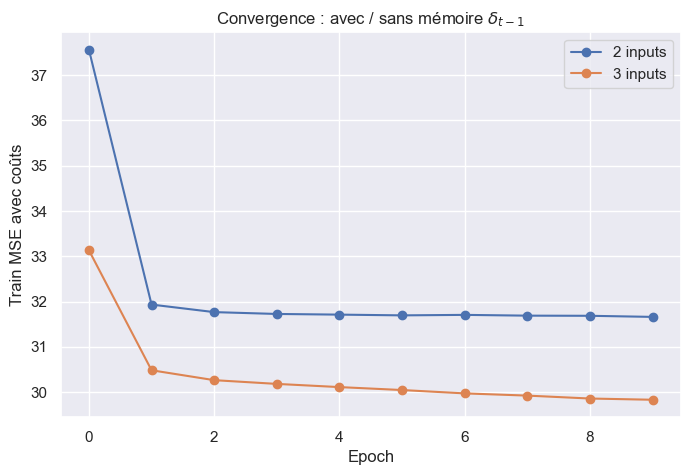

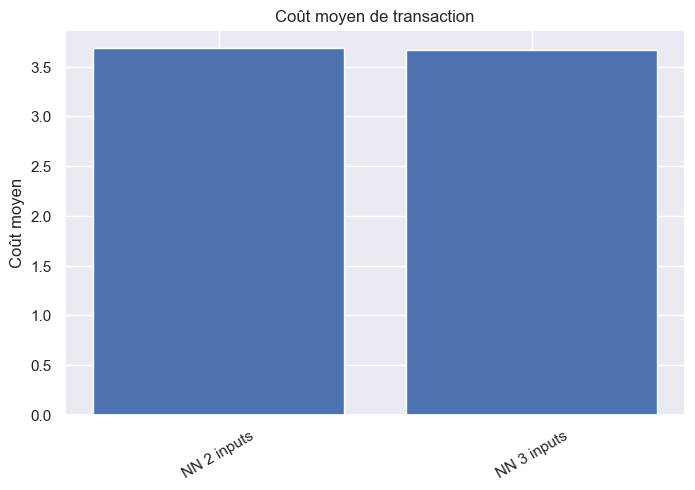

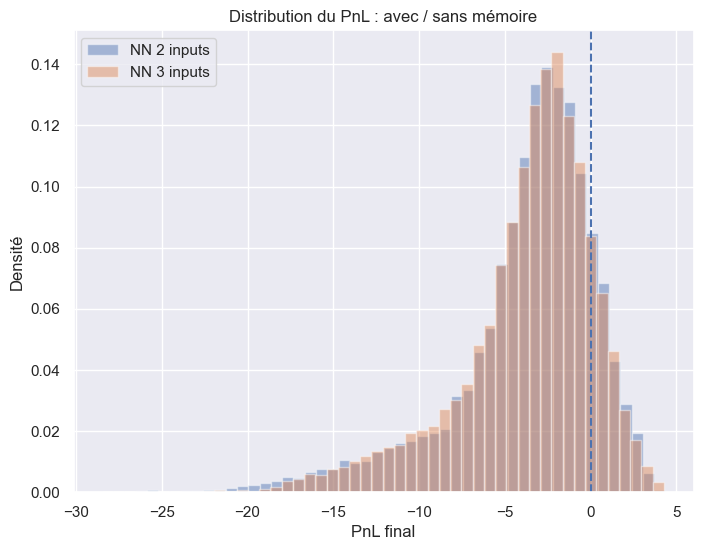

In [113]:
results = {}
train_losses = {} #stock les loss 

eps = 5*1e-2

sample_S_raw = simulation_actif(N, T, M, S0, sigma, r)

times = np.arange(N + 1) * T / N

moyenne = S0 * np.exp(r * times)
ecart_type = S0 * np.exp(r * times) * np.sqrt(np.exp(sigma**2 * times) - 1)
ecart_type[0] = 1.0

sample_S_norm = (sample_S_raw - moyenne) / ecart_type

S_act = sample_S_raw * np.exp(-r * times)
dS = np.diff(S_act, axis=1)

tau_grid = (T - times[:-1]) / T

data_np = np.stack([
    sample_S_norm[:, :-1],
    np.repeat(tau_grid.reshape(1, -1), M, axis=0)
], axis=2)

phi_np = payoff_put(sample_S_raw[:, -1], K) * np.exp(-r * T)

data = torch.from_numpy(data_np).float().to(device)
dS_torch = torch.from_numpy(dS).float().to(device)
phi = torch.from_numpy(phi_np).float().to(device)
S_act_torch = torch.from_numpy(S_act).float().to(device)

P0_val = float(price_put_BS(S0, T, r, sigma, K))
P0 = torch.tensor(P0_val, dtype=torch.float32, device=device)

model_2 = NeuralNetwork(input_size=2, hidden_size=H, output_size=1).to(device)
optimizer = torch.optim.Adam(model_2.parameters(), lr=learning_rate)

size_tot = data.shape[0]
nb_batch = size_tot // batch_size

losses_2 = []

for epoch in range(n_epochs):

    perm = torch.randperm(size_tot, device=device)
    epoch_loss = 0.0

    for j in range(nb_batch):

        idx = perm[j * batch_size:(j + 1) * batch_size]

        X_batch = data[idx]
        dS_batch = dS_torch[idx]
        phi_batch = phi[idx]
        S_batch = S_act_torch[idx]

        q = model_2(X_batch).squeeze(-1)

        delta_pnl = (q * dS_batch).sum(dim=1)

        q_prev = torch.cat([torch.zeros(q.shape[0], 1, device=device), q], dim=1)
        q_next = torch.cat([q, torch.zeros(q.shape[0], 1, device=device)], dim=1)

        costs = eps * torch.sum(S_batch * torch.abs(q_next - q_prev), dim=1)

        pnl = P0 - phi_batch + delta_pnl - costs

        loss = torch.mean(pnl**2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= nb_batch
    losses_2.append(epoch_loss)

    print(f"2 inputs | Epoch {epoch+1}/{n_epochs} | Loss = {epoch_loss:.6f}")

train_losses["2 inputs"] = losses_2

model_3 = NeuralNetwork(input_size=3, hidden_size=H, output_size=1).to(device)
optimizer = torch.optim.Adam(model_3.parameters(), lr=learning_rate)

losses_3 = []

for epoch in range(n_epochs):

    perm = torch.randperm(size_tot, device=device)
    epoch_loss = 0.0

    for j in range(nb_batch):

        idx = perm[j * batch_size:(j + 1) * batch_size]

        X_batch = data[idx]
        dS_batch = dS_torch[idx]
        phi_batch = phi[idx]
        S_batch = S_act_torch[idx]

        batch_n = X_batch.shape[0]

        delta_prev = torch.zeros(batch_n, device=device)
        q_list = []

        for t in range(N):

            S_t = X_batch[:, t, 0]
            tau_t = X_batch[:, t, 1]

            input_t = torch.stack([S_t, tau_t, delta_prev], dim=1)

            delta_t = model_3(input_t).squeeze(-1)

            q_list.append(delta_t)
            delta_prev = delta_t

        q = torch.stack(q_list, dim=1)

        delta_pnl = (q * dS_batch).sum(dim=1)

        q_prev = torch.cat([torch.zeros(batch_n, 1, device=device), q], dim=1)
        q_next = torch.cat([q, torch.zeros(batch_n, 1, device=device)], dim=1)

        costs = eps * torch.sum(S_batch * torch.abs(q_next - q_prev), dim=1)

        pnl = P0 - phi_batch + delta_pnl - costs

        loss = torch.mean(pnl**2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= nb_batch
    losses_3.append(epoch_loss)

    print(f"3 inputs | Epoch {epoch+1}/{n_epochs} | Loss = {epoch_loss:.6f}")

train_losses["3 inputs"] = losses_3

np.random.seed(42)
sample_S_test = simulation_actif(N, T, M_test, S0, sigma, r)

times = np.arange(N + 1) * T / N

moyenne = S0 * np.exp(r * times)
ecart_type = S0 * np.exp(r * times) * np.sqrt(np.exp(sigma**2 * times) - 1)
ecart_type[0] = 1.0

sample_norm_test = (sample_S_test - moyenne) / ecart_type

tau_grid = (T - np.arange(N) * T / N) / T
tau_mat = np.repeat(tau_grid.reshape(1, -1), M_test, axis=0)

X_test_np = np.stack([sample_norm_test[:, :-1], tau_mat], axis=2)
X_test = torch.from_numpy(X_test_np).float().to(device)

sample_S_test_disc = sample_S_test * np.exp(-r * times)
dS_test = np.diff(sample_S_test_disc, axis=1)

payoff_disc = np.exp(-r * T) * np.maximum(K - sample_S_test[:, -1], 0)

model_2.eval()

with torch.no_grad():
    q_2 = model_2(X_test).squeeze(-1).cpu().numpy()

q_prev_2 = np.concatenate([np.zeros((M_test, 1)), q_2], axis=1)
q_next_2 = np.concatenate([q_2, np.zeros((M_test, 1))], axis=1)

costs_2 = eps * np.sum(
    sample_S_test_disc * np.abs(q_next_2 - q_prev_2),
    axis=1
)

pnl_2 = (
    P0_val
    - payoff_disc
    + np.sum(q_2 * dS_test, axis=1)
    - costs_2
)

results["NN 2 inputs"] = {
    "pnl": pnl_2,
    "q": q_2,
    "costs": costs_2,
    "q_prev": q_prev_2,
    "q_next": q_next_2
}

model_3.eval()

delta_prev = np.zeros(M_test)
q_3_list = []

with torch.no_grad():

    for t in range(N):

        S_t = sample_norm_test[:, t]
        tau_t = tau_mat[:, t]

        X_input = np.stack([S_t, tau_t, delta_prev], axis=1)
        X_input = torch.from_numpy(X_input).float().to(device)

        delta_t = model_3(X_input).squeeze(-1).cpu().numpy()

        q_3_list.append(delta_t)
        delta_prev = delta_t

q_3 = np.stack(q_3_list, axis=1)

q_prev_3 = np.concatenate([np.zeros((M_test, 1)), q_3], axis=1)
q_next_3 = np.concatenate([q_3, np.zeros((M_test, 1))], axis=1)

costs_3 = eps * np.sum(
    sample_S_test_disc * np.abs(q_next_3 - q_prev_3),
    axis=1
)

pnl_3 = (
    P0_val
    - payoff_disc
    + np.sum(q_3 * dS_test, axis=1)
    - costs_3
)

results["NN 3 inputs"] = {
    "pnl": pnl_3,
    "q": q_3,
    "costs": costs_3,
    "q_prev": q_prev_3,
    "q_next": q_next_3
}

def compute_metrics(pnl, costs, q_prev, q_next, name):
    q01 = np.quantile(pnl, 0.01)
    q99 = np.quantile(pnl, 0.99)

    return {
        "Model": name,
        "Bias": np.mean(pnl),
        "Std": np.std(pnl),
        "Q01": q01,
        "Q99": q99,
        "CVaR_99_left": pnl[pnl <= q01].mean(),
        "Mean_cost": np.mean(costs),
        "Mean_turnover": np.mean(np.sum(np.abs(q_next - q_prev), axis=1))
    }

metrics_df = pd.DataFrame([
    compute_metrics(
        results[name]["pnl"],
        results[name]["costs"],
        results[name]["q_prev"],
        results[name]["q_next"],
        name
    )
    for name in results.keys()
])

print(metrics_df.round(6))

fig, ax = plt.subplots(figsize=(8, 5))

for name, losses in train_losses.items():
    ax.plot(losses, marker="o", label=name)

ax.set_xlabel("Epoch")
ax.set_ylabel("Train MSE avec coûts")
ax.set_title(r"Convergence : avec / sans mémoire $\delta_{t-1}$")
ax.legend()
plt.show()


fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(metrics_df["Model"], metrics_df["Mean_cost"])
ax.set_ylabel("Coût moyen")
ax.set_title("Coût moyen de transaction")
plt.xticks(rotation=30)
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))

for name in results.keys():
    ax.hist(
        results[name]["pnl"],
        bins=50,
        density=True,
        alpha=0.45,
        label=name
    )

ax.axvline(0, linestyle="--")
ax.set_xlabel("PnL final")
ax.set_ylabel("Densité")
ax.set_title("Distribution du PnL : avec / sans mémoire")
ax.legend()
plt.show()

Essayons maintenant de faire varier les architectures et de voir l'influence du nombre de neurones sur la distribution du PnL


H = 16
2 inputs | H=16 | Epoch 1/10 | Loss=44.135245
2 inputs | H=16 | Epoch 2/10 | Loss=33.948773
2 inputs | H=16 | Epoch 3/10 | Loss=33.348982
2 inputs | H=16 | Epoch 4/10 | Loss=32.504537
2 inputs | H=16 | Epoch 5/10 | Loss=32.326449
2 inputs | H=16 | Epoch 6/10 | Loss=32.255449
2 inputs | H=16 | Epoch 7/10 | Loss=32.203989
2 inputs | H=16 | Epoch 8/10 | Loss=32.154856
2 inputs | H=16 | Epoch 9/10 | Loss=32.114276
2 inputs | H=16 | Epoch 10/10 | Loss=32.070640
3 inputs | H=16 | Epoch 1/10 | Loss=36.968768
3 inputs | H=16 | Epoch 2/10 | Loss=31.537756
3 inputs | H=16 | Epoch 3/10 | Loss=31.372175
3 inputs | H=16 | Epoch 4/10 | Loss=31.263960
3 inputs | H=16 | Epoch 5/10 | Loss=31.169606
3 inputs | H=16 | Epoch 6/10 | Loss=31.067667
3 inputs | H=16 | Epoch 7/10 | Loss=30.994005
3 inputs | H=16 | Epoch 8/10 | Loss=30.939832
3 inputs | H=16 | Epoch 9/10 | Loss=30.882518
3 inputs | H=16 | Epoch 10/10 | Loss=30.788102

H = 32
2 inputs | H=32 | Epoch 1/10 | Loss=35.670411
2 inputs | H=32 

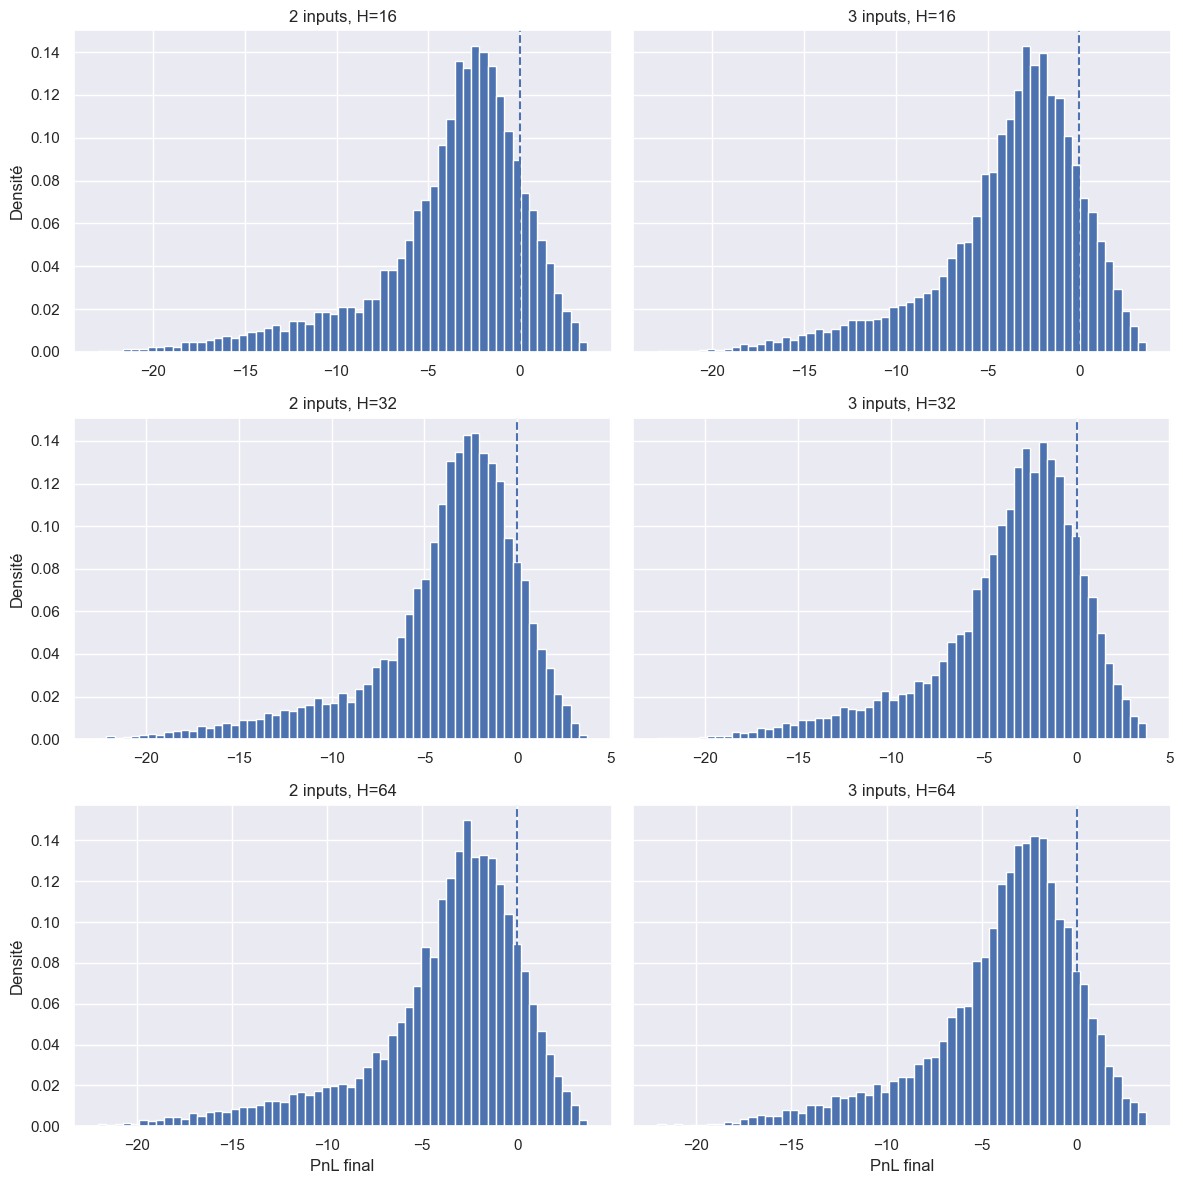

In [114]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

H_range = [16, 32, 64]
eps = 5e-2
M_test = 10**4

results = {}
train_losses = {}
metrics_rows = []

sample_S_raw = simulation_actif(N, T, M, S0, sigma, r)

times = np.arange(N + 1) * T / N

moyenne = S0 * np.exp(r * times)
ecart_type = S0 * np.exp(r * times) * np.sqrt(np.exp(sigma**2 * times) - 1)
ecart_type[0] = 1.0

sample_S_norm = (sample_S_raw - moyenne) / ecart_type

S_act = sample_S_raw * np.exp(-r * times)
dS_np = np.diff(S_act, axis=1)

tau_grid = (T - times[:-1]) / T

data_np = np.stack([
    sample_S_norm[:, :-1],
    np.repeat(tau_grid.reshape(1, -1), M, axis=0)
], axis=2)

phi_np = payoff_put(sample_S_raw[:, -1], K) * np.exp(-r * T)

data = torch.from_numpy(data_np).float().to(device)
dS_torch = torch.from_numpy(dS_np).float().to(device)
phi = torch.from_numpy(phi_np).float().to(device)
S_act_torch = torch.from_numpy(S_act).float().to(device)

P0_val = float(price_put_BS(S0, T, r, sigma, K))
P0 = torch.tensor(P0_val, dtype=torch.float32, device=device)

size_tot = data.shape[0]
nb_batch = size_tot // batch_size

np.random.seed(42)
sample_S_test = simulation_actif(N, T, M_test, S0, sigma, r)

sample_norm_test = (sample_S_test - moyenne) / ecart_type

tau_mat = np.repeat(tau_grid.reshape(1, -1), M_test, axis=0)

X_test_np = np.stack([sample_norm_test[:, :-1], tau_mat], axis=2)
X_test = torch.from_numpy(X_test_np).float().to(device)

sample_S_test_disc = sample_S_test * np.exp(-r * times)
dS_test = np.diff(sample_S_test_disc, axis=1)

payoff_disc = np.exp(-r * T) * np.maximum(K - sample_S_test[:, -1], 0)


def compute_metrics(pnl, costs, q_prev, q_next, name, H=None):
    q01 = np.quantile(pnl, 0.01)
    q99 = np.quantile(pnl, 0.99)

    return {
        "Model": name,
        "H": H,
        "MSE": np.mean(pnl**2),
        "Mean": np.mean(pnl),
        "Variance": np.var(pnl),
        "Std": np.std(pnl),
        "Q01": q01,
        "Q99": q99,
        "CVaR_99_left": pnl[pnl <= q01].mean(),
        "Mean_cost": np.mean(costs)
    }



for H in H_range:

    print(f"\n==============================")
    print(f"H = {H}")
    print("==============================")


    model_2 = NeuralNetwork(input_size=2, hidden_size=H, output_size=1).to(device)
    optimizer = torch.optim.Adam(model_2.parameters(), lr=learning_rate)

    losses_2 = []

    for epoch in range(n_epochs):

        perm = torch.randperm(size_tot, device=device)
        epoch_loss = 0.0

        for j in range(nb_batch):

            idx = perm[j * batch_size:(j + 1) * batch_size]

            X_batch = data[idx]
            dS_batch = dS_torch[idx]
            phi_batch = phi[idx]
            S_batch = S_act_torch[idx]

            q = model_2(X_batch).squeeze(-1)

            delta_pnl = (q * dS_batch).sum(dim=1)

            q_prev = torch.cat(
                [torch.zeros(q.shape[0], 1, device=device), q],
                dim=1
            )
            q_next = torch.cat(
                [q, torch.zeros(q.shape[0], 1, device=device)],
                dim=1
            )

            costs = eps * torch.sum(
                S_batch * torch.abs(q_next - q_prev),
                dim=1
            )

            pnl = P0 - phi_batch + delta_pnl - costs
            loss = torch.mean(pnl**2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= nb_batch
        losses_2.append(epoch_loss)

        print(f"2 inputs | H={H} | Epoch {epoch+1}/{n_epochs} | Loss={epoch_loss:.6f}")

    train_losses[f"2 inputs H={H}"] = losses_2

    model_2.eval()
    with torch.no_grad():
        q_2 = model_2(X_test).squeeze(-1).cpu().numpy()

    q_prev_2 = np.concatenate([np.zeros((M_test, 1)), q_2], axis=1)
    q_next_2 = np.concatenate([q_2, np.zeros((M_test, 1))], axis=1)

    costs_2 = eps * np.sum(
        sample_S_test_disc * np.abs(q_next_2 - q_prev_2),
        axis=1
    )

    pnl_2 = (
        P0_val
        - payoff_disc
        + np.sum(q_2 * dS_test, axis=1)
        - costs_2
    )

    name_2 = f"NN 2 inputs H={H}"

    results[name_2] = {
        "pnl": pnl_2,
        "q": q_2,
        "costs": costs_2,
        "q_prev": q_prev_2,
        "q_next": q_next_2,
    }

    metrics_rows.append(
        compute_metrics(
            pnl_2,
            costs_2,
            q_prev_2,
            q_next_2,
            "NN 2 inputs",
            H=H
        )
    )

    # modèle 3 inputs

    model_3 = NeuralNetwork(input_size=3, hidden_size=H, output_size=1).to(device)
    optimizer = torch.optim.Adam(model_3.parameters(), lr=learning_rate)

    losses_3 = []

    for epoch in range(n_epochs):

        perm = torch.randperm(size_tot, device=device)
        epoch_loss = 0.0

        for j in range(nb_batch):

            idx = perm[j * batch_size:(j + 1) * batch_size]

            X_batch = data[idx]
            dS_batch = dS_torch[idx]
            phi_batch = phi[idx]
            S_batch = S_act_torch[idx]

            batch_n = X_batch.shape[0]

            delta_prev = torch.zeros(batch_n, device=device)
            q_list = []

            for t in range(N):

                S_t = X_batch[:, t, 0]
                tau_t = X_batch[:, t, 1]

                input_t = torch.stack([S_t, tau_t, delta_prev], dim=1)

                delta_t = model_3(input_t).squeeze(-1)

                q_list.append(delta_t)
                delta_prev = delta_t

            q = torch.stack(q_list, dim=1)

            delta_pnl = (q * dS_batch).sum(dim=1)

            q_prev = torch.cat(
                [torch.zeros(batch_n, 1, device=device), q],
                dim=1
            )
            q_next = torch.cat(
                [q, torch.zeros(batch_n, 1, device=device)],
                dim=1
            )

            costs = eps * torch.sum(
                S_batch * torch.abs(q_next - q_prev),
                dim=1
            )

            pnl = P0 - phi_batch + delta_pnl - costs
            loss = torch.mean(pnl**2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= nb_batch
        losses_3.append(epoch_loss)

        print(f"3 inputs | H={H} | Epoch {epoch+1}/{n_epochs} | Loss={epoch_loss:.6f}")

    train_losses[f"3 inputs H={H}"] = losses_3


    model_3.eval()

    delta_prev = np.zeros(M_test)
    q_3_list = []

    with torch.no_grad():

        for t in range(N):

            S_t = sample_norm_test[:, t]
            tau_t = tau_mat[:, t]

            X_input = np.stack([S_t, tau_t, delta_prev], axis=1)
            X_input = torch.from_numpy(X_input).float().to(device)

            delta_t = model_3(X_input).squeeze(-1).cpu().numpy()

            q_3_list.append(delta_t)
            delta_prev = delta_t

    q_3 = np.stack(q_3_list, axis=1)

    q_prev_3 = np.concatenate([np.zeros((M_test, 1)), q_3], axis=1)
    q_next_3 = np.concatenate([q_3, np.zeros((M_test, 1))], axis=1)

    costs_3 = eps * np.sum(
        sample_S_test_disc * np.abs(q_next_3 - q_prev_3),
        axis=1
    )

    pnl_3 = (
        P0_val
        - payoff_disc
        + np.sum(q_3 * dS_test, axis=1)
        - costs_3
    )

    name_3 = f"NN 3 inputs H={H}"

    results[name_3] = {
        "pnl": pnl_3,
        "q": q_3,
        "costs": costs_3,
        "q_prev": q_prev_3,
        "q_next": q_next_3,
    }

    metrics_rows.append(
        compute_metrics(
            pnl_3,
            costs_3,
            q_prev_3,
            q_next_3,
            "NN 3 inputs",
            H=H
        )
    )

metrics_df = pd.DataFrame(metrics_rows)
print(metrics_df.round(6))



# grille de distribution

fig, axes = plt.subplots(
    len(H_range),
    2,
    figsize=(12, 4 * len(H_range)),
    sharex="row",
    sharey="row"
)

for i, H in enumerate(H_range):

    pnl_2 = results[f"NN 2 inputs H={H}"]["pnl"]
    pnl_3 = results[f"NN 3 inputs H={H}"]["pnl"]

    all_pnl = np.concatenate([pnl_2, pnl_3])

    bins = np.linspace(
        np.quantile(all_pnl, 0.001),
        np.quantile(all_pnl, 0.999),
        60
    )

    axes[i, 0].hist(pnl_2, bins=bins, density=True)
    axes[i, 0].set_title(f"2 inputs, H={H}")
    axes[i, 0].set_ylabel("Densité")

    axes[i, 1].hist(pnl_3, bins=bins, density=True)
    axes[i, 1].set_title(f"3 inputs, H={H}")

    axes[i, 0].axvline(0, linestyle="--")
    axes[i, 1].axvline(0, linestyle="--")

axes[-1, 0].set_xlabel("PnL final")
axes[-1, 1].set_xlabel("PnL final")

plt.tight_layout()
plt.show()

### Introduction critère CVaR 

Ce passage est inspirée du papier. Au lieu de prendre comme critère la minimisation du PnL pour converger vers 0, on prend le critère de la CVaR 50% et 99% et voir l'impact sur la distribution du PnL.

In [115]:
H = 32
eps = 1e-2
M_test = 10**4
M = 10**7

loss_specs = [
    ("MSE", None),
    ("CVaR_50", 0.50),
    ("CVaR_99", 0.99)
]

models = {}
train_losses = {}
etas = {}

sample_S_raw = simulation_actif(N, T, M, S0, sigma, r)

times = np.arange(N + 1) * T / N

moyenne = S0 * np.exp(r * times)
ecart_type = S0 * np.exp(r * times) * np.sqrt(np.exp(sigma**2 * times) - 1)
ecart_type[0] = 1.0

sample_S_norm = (sample_S_raw - moyenne) / ecart_type

S_act = sample_S_raw * np.exp(-r * times)
dS = np.diff(S_act, axis=1)

tau_grid = (T - times[:-1]) / T

data_np = np.stack([
    sample_S_norm[:, :-1],
    np.repeat(tau_grid.reshape(1, -1), M, axis=0)
], axis=2)

phi_np = payoff_put(sample_S_raw[:, -1], K) * np.exp(-r * T)

data = torch.from_numpy(data_np).float().to(device)
dS_torch = torch.from_numpy(dS).float().to(device)
phi = torch.from_numpy(phi_np).float().to(device)
S_act_torch = torch.from_numpy(S_act).float().to(device)

P0_val = float(price_put_BS(S0, T, r, sigma, K))
P0 = torch.tensor(P0_val, dtype=torch.float32, device=device)

size_tot = data.shape[0]
nb_batch = size_tot // batch_size

def forward_with_memory(model, X_batch, dS_batch, S_batch, phi_batch,
                        loss_name, alpha=None, eta=None):
    """
    Cette fonction fait passer un batch de trajectoires dans le réseau,
    calcule la stratégie de couverture, puis le PnL et la loss associée.
    """

    batch_n = X_batch.shape[0]

    delta_prev = torch.zeros(batch_n, device=device)

    q_list = []
    for t in range(N):
        S_t = X_batch[:, t, 0]

        tau_t = X_batch[:, t, 1]

        input_t = torch.stack([S_t, tau_t, delta_prev], dim=1)

        delta_t = model(input_t).squeeze(-1)

        q_list.append(delta_t)

        delta_prev = delta_t

    q = torch.stack(q_list, dim=1)

    delta_pnl = (q * dS_batch).sum(dim=1)

    q_prev = torch.cat(
        [torch.zeros(batch_n, 1, device=device), q],
        dim=1
    )


    q_next = torch.cat(
        [q, torch.zeros(batch_n, 1, device=device)],
        dim=1
    )

    costs = eps * torch.sum(
        S_batch * torch.abs(q_next - q_prev),
        dim=1
    )

    pnl = P0 - phi_batch + delta_pnl - costs

    # Cas 1 : loss quadratique classique
    if loss_name == "MSE":
        loss = torch.mean(pnl**2)

    # Cas 2 : loss CVaR
    else:
        # On définit les pertes comme l'opposé du PnL
        losses = -pnl

        # Formulation optimisable de la CVaR :
        # eta + 1/(1-alpha) * E[(L - eta)^+]
        loss = eta + (1 / (1 - alpha)) * torch.mean(
            torch.relu(losses - eta)
        )

    return loss, pnl, q, costs

for loss_name, alpha in loss_specs:

    print(f"\n===== Training {loss_name} =====")

    model = NeuralNetwork(input_size=3, hidden_size=H, output_size=1).to(device)

    if loss_name == "MSE":
        eta = None
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    else:
        eta = torch.nn.Parameter(torch.tensor(0.0, device=device))
        optimizer = torch.optim.Adam(
            list(model.parameters()) + [eta],
            lr=learning_rate
        )

    losses_epoch = []

    for epoch in range(n_epochs):

        perm = torch.randperm(size_tot, device=device)
        epoch_loss = 0.0

        for j in range(nb_batch):

            idx = perm[j * batch_size:(j + 1) * batch_size]

            X_batch = data[idx]
            dS_batch = dS_torch[idx]
            phi_batch = phi[idx]
            S_batch = S_act_torch[idx]

            loss, pnl, q, costs = forward_with_memory(
                model=model,
                X_batch=X_batch,
                dS_batch=dS_batch,
                S_batch=S_batch,
                phi_batch=phi_batch,
                loss_name=loss_name,
                alpha=alpha,
                eta=eta
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= nb_batch
        losses_epoch.append(epoch_loss)

        if eta is not None:
            print(f"{loss_name} | Epoch {epoch+1}/{n_epochs} | Loss={epoch_loss:.6f} | eta={eta.item():.6f}")
        else:
            print(f"{loss_name} | Epoch {epoch+1}/{n_epochs} | Loss={epoch_loss:.6f}")

    models[loss_name] = model
    train_losses[loss_name] = losses_epoch

    if eta is not None:
        etas[loss_name] = eta.item()


===== Training MSE =====
MSE | Epoch 1/10 | Loss=8.177421
MSE | Epoch 2/10 | Loss=7.773865
MSE | Epoch 3/10 | Loss=7.759410
MSE | Epoch 4/10 | Loss=7.756039
MSE | Epoch 5/10 | Loss=7.753166
MSE | Epoch 6/10 | Loss=7.751753
MSE | Epoch 7/10 | Loss=7.749410
MSE | Epoch 8/10 | Loss=7.747027
MSE | Epoch 9/10 | Loss=7.746384
MSE | Epoch 10/10 | Loss=7.744673

===== Training CVaR_50 =====
CVaR_50 | Epoch 1/10 | Loss=3.176604 | eta=0.954364
CVaR_50 | Epoch 2/10 | Loss=3.137927 | eta=0.934196
CVaR_50 | Epoch 3/10 | Loss=3.130910 | eta=0.947666
CVaR_50 | Epoch 4/10 | Loss=3.124963 | eta=0.959895
CVaR_50 | Epoch 5/10 | Loss=3.121244 | eta=0.942048
CVaR_50 | Epoch 6/10 | Loss=3.119691 | eta=0.926772
CVaR_50 | Epoch 7/10 | Loss=3.118789 | eta=0.944613
CVaR_50 | Epoch 8/10 | Loss=3.115408 | eta=0.941949
CVaR_50 | Epoch 9/10 | Loss=3.111954 | eta=0.934655
CVaR_50 | Epoch 10/10 | Loss=3.109827 | eta=0.945629

===== Training CVaR_99 =====
CVaR_99 | Epoch 1/10 | Loss=42.153557 | eta=6.446454
CVaR_99 |

In [116]:
np.random.seed(42)

sample_S_test = simulation_actif(N, T, M_test, S0, sigma, r)

times = np.arange(N + 1) * T / N

moyenne = S0 * np.exp(r * times)
ecart_type = S0 * np.exp(r * times) * np.sqrt(np.exp(sigma**2 * times) - 1)
ecart_type[0] = 1.0

sample_norm_test = (sample_S_test - moyenne) / ecart_type

tau_grid = (T - np.arange(N) * T / N) / T
tau_mat = np.repeat(tau_grid.reshape(1, -1), M_test, axis=0)

sample_S_test_disc = sample_S_test * np.exp(-r * times)
dS_test = np.diff(sample_S_test_disc, axis=1)

payoff_disc = np.exp(-r * T) * np.maximum(K - sample_S_test[:, -1], 0)

def evaluate_memory_model(model):

    model.eval()

    delta_prev = np.zeros(M_test)
    q_list = []

    with torch.no_grad():

        for t in range(N):

            S_t = sample_norm_test[:, t]
            tau_t = tau_mat[:, t]

            X_input = np.stack([S_t, tau_t, delta_prev], axis=1)
            X_input = torch.from_numpy(X_input).float().to(device)

            delta_t = model(X_input).squeeze(-1).cpu().numpy()

            q_list.append(delta_t)
            delta_prev = delta_t

    q = np.stack(q_list, axis=1)

    q_prev = np.concatenate([np.zeros((M_test, 1)), q], axis=1)
    q_next = np.concatenate([q, np.zeros((M_test, 1))], axis=1)

    costs = eps * np.sum(
        sample_S_test_disc * np.abs(q_next - q_prev),
        axis=1
    )

    delta_pnl = np.sum(q * dS_test, axis=1)

    pnl = (
        P0_val
        - payoff_disc
        + delta_pnl
        - costs
    )

    return pnl, q, costs, q_prev, q_next

In [117]:
eval_results = {}

for loss_name, model in models.items():

    pnl, q, costs, q_prev, q_next = evaluate_memory_model(model)

    eval_results[loss_name] = {
        "pnl": pnl,
        "q": q,
        "costs": costs,
        "q_prev": q_prev,
        "q_next": q_next
    }

In [118]:
def cvar_left(pnl, alpha):
    threshold = np.quantile(pnl, 1 - alpha)
    return pnl[pnl <= threshold].mean()

def compute_metrics(name, obj):

    pnl = obj["pnl"]
    costs = obj["costs"]
    q_prev = obj["q_prev"]
    q_next = obj["q_next"]

    return {
        "Model": name,
        "MSE": np.mean(pnl**2),
        "Bias": np.mean(pnl),
        "Std": np.std(pnl),
        "Q01": np.quantile(pnl, 0.01),
        "Q05": np.quantile(pnl, 0.05),
        "Q50": np.quantile(pnl, 0.50),
        "Q95": np.quantile(pnl, 0.95),
        "Q99": np.quantile(pnl, 0.99),
        "CVaR_50_left": cvar_left(pnl, 0.50),
        "CVaR_95_left": cvar_left(pnl, 0.95),
        "CVaR_99_left": cvar_left(pnl, 0.99),
        "Mean_cost": np.mean(costs),
        "Mean_turnover": np.mean(np.sum(np.abs(q_next - q_prev), axis=1))
    }

metrics_df = pd.DataFrame([
    compute_metrics(name, obj)
    for name, obj in eval_results.items()
])

print(metrics_df.round(6))

     Model        MSE      Bias       Std       Q01       Q05       Q50  \
0      MSE   7.685196 -1.314375  2.440822 -7.957565 -5.453632 -1.209786   
1  CVaR_50   8.238711 -1.196484  2.609049 -9.115682 -5.705490 -0.981772   
2  CVaR_99  10.211452 -1.273756  2.930699 -7.226264 -5.769462 -1.493037   

        Q95       Q99  CVaR_50_left  CVaR_95_left  CVaR_99_left  Mean_cost  \
0  2.503474  4.242426     -3.185979     -7.037397     -9.637019   1.279541   
1  2.697003  4.597480     -3.100156     -7.888342    -11.551115   1.167552   
2  3.852478  5.352866     -3.670250     -6.719937     -8.155532   1.204437   

   Mean_turnover  
0       1.390743  
1       1.270958  
2       1.301398  


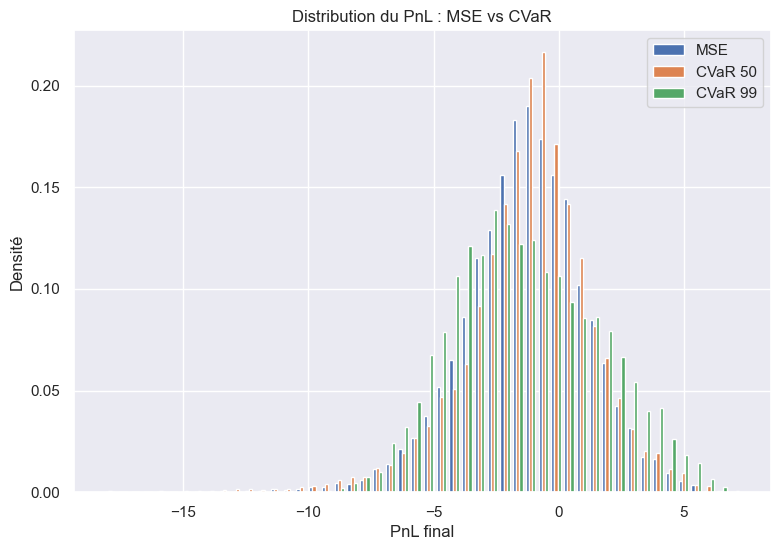

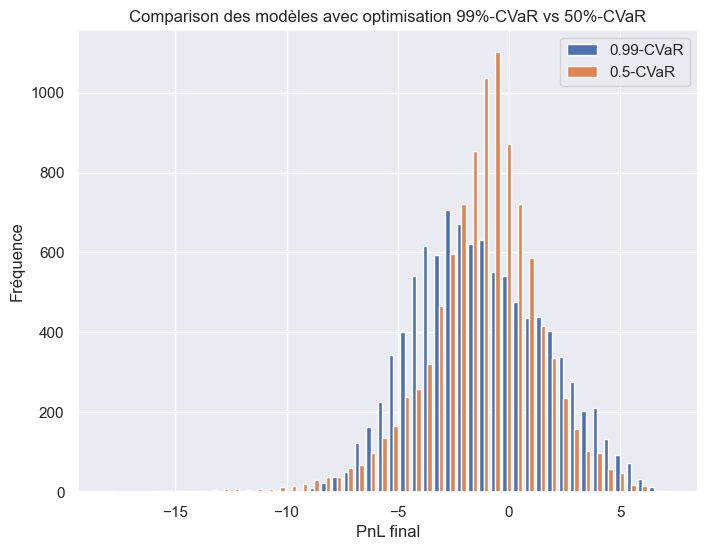

  Model      Bias      Std       Q01      Q99  Mean_cost
    MSE -1.314375 2.440822 -7.957565 4.242426   1.279541
CVaR_50 -1.196484 2.609049 -9.115682 4.597480   1.167552
CVaR_99 -1.273756 2.930699 -7.226264 5.352866   1.204437
\begin{table}
\caption{Statistiques du P\&L selon la fonction de perte}
\label{tab:pnl_loss_comparison}
\begin{tabular}{lrrrrr}
\toprule
Model & Bias & Std & Q01 & Q99 & Mean_cost \\
\midrule
MSE & -1.314375 & 2.440822 & -7.957565 & 4.242426 & 1.279541 \\
CVaR_50 & -1.196484 & 2.609049 & -9.115682 & 4.597480 & 1.167552 \\
CVaR_99 & -1.273756 & 2.930699 & -7.226264 & 5.352866 & 1.204437 \\
\bottomrule
\end{tabular}
\end{table}



In [119]:
pnl_mse = eval_results["MSE"]["pnl"]
pnl_cvar50 = eval_results["CVaR_50"]["pnl"]
pnl_cvar99 = eval_results["CVaR_99"]["pnl"]

bins = 50
all_pnl = np.concatenate([pnl_mse, pnl_cvar50, pnl_cvar99])

counts_mse, bin_edges = np.histogram(pnl_mse, bins=bins, range=(all_pnl.min(), all_pnl.max()), density=True)
counts_cvar50, _ = np.histogram(pnl_cvar50, bins=bin_edges, density=True)
counts_cvar99, _ = np.histogram(pnl_cvar99, bins=bin_edges, density=True)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
width = bin_width * 0.25

fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(bin_centers - width, counts_mse, width=width, label="MSE")
ax.bar(bin_centers, counts_cvar50, width=width, label="CVaR 50")
ax.bar(bin_centers + width, counts_cvar99, width=width, label="CVaR 99")

ax.set_xlabel("PnL final")
ax.set_ylabel("Densité")
ax.set_title("Distribution du PnL : MSE vs CVaR")
ax.legend()

plt.show()

bins = 50
all_pnl = np.concatenate([pnl_cvar99, pnl_cvar50])

counts_99, bin_edges = np.histogram(
    pnl_cvar99,
    bins=bins,
    range=(all_pnl.min(), all_pnl.max()),
    density=False
)

counts_50, _ = np.histogram(
    pnl_cvar50,
    bins=bin_edges,
    density=False
)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
width = bin_width * 0.4

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(
    bin_centers - width / 2,
    counts_99,
    width=width,
    label="0.99-CVaR"
)

ax.bar(
    bin_centers + width / 2,
    counts_50,
    width=width,
    label="0.5-CVaR"
)

ax.set_xlabel("PnL final")
ax.set_ylabel("Fréquence")
ax.set_title("Comparison des modèles avec optimisation 99%-CVaR vs 50%-CVaR")
ax.legend()

plt.show()

plot_df = metrics_df[metrics_df["Model"].isin(["MSE", "CVaR_50", "CVaR_99"])]

table_df = metrics_df[
    metrics_df["Model"].isin(["MSE", "CVaR_50", "CVaR_99"])
][
    ["Model", "Bias", "Std", "Q01", "Q99", "Mean_cost"]
].copy()

print(table_df.round(6).to_string(index=False))

latex_table = table_df.round(6).to_latex(
    index=False,
    float_format="%.6f",
    caption=r"Statistiques du P\&L selon la fonction de perte",
    label="tab:pnl_loss_comparison"
)

print(latex_table)

# Sensibilités

Testons la sensibilté du modèle à des données de test différentes, en modifiant par exemple le strike ou la volatilité des actifs. 

In [121]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


sigma_train = 0.25         # volatilité d'entraînement
sigma_test_range = [0.10,  0.20, 0.30]
K = 100


eps = 5e-2
H = 32 #largeur de couche fixée à 32
M_test = 10**4
M = 10**6

results = []
pnl_by_sigma = {}


sample_S_raw = simulation_actif(N, T, M, S0, sigma_train, r)

times = np.arange(N + 1) * T / N

moyenne = S0 * np.exp(r * times)
ecart_type = S0 * np.exp(r * times) * np.sqrt(np.exp(sigma_train**2 * times) - 1)
ecart_type[0] = 1.0

sample_S_norm = (sample_S_raw - moyenne) / ecart_type

S_act = sample_S_raw * np.exp(-r * times)
dS_np = np.diff(S_act, axis=1)

tau_grid = (T - times[:-1]) / T

data_np = np.stack([
    sample_S_norm[:, :-1],
    np.repeat(tau_grid.reshape(1, -1), M, axis=0)
], axis=2)

phi_np = payoff_put(sample_S_raw[:, -1], K) * np.exp(-r * T)

data = torch.from_numpy(data_np).float().to(device)
dS_torch = torch.from_numpy(dS_np).float().to(device)
phi = torch.from_numpy(phi_np).float().to(device)
S_act_torch = torch.from_numpy(S_act).float().to(device)

P0_val = float(price_put_BS(S0, T, r, sigma_train, K))
P0 = torch.tensor(P0_val, dtype=torch.float32, device=device)

model = NeuralNetwork(input_size=3, hidden_size=H, output_size=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

size_tot = data.shape[0]
nb_batch = size_tot // batch_size

for epoch in range(n_epochs):

    perm = torch.randperm(size_tot, device=device)
    epoch_loss = 0.0

    for j in range(nb_batch):

        idx = perm[j * batch_size:(j + 1) * batch_size]

        X_batch = data[idx]
        dS_batch = dS_torch[idx]
        phi_batch = phi[idx]
        S_batch = S_act_torch[idx]

        batch_n = X_batch.shape[0]

        delta_prev = torch.zeros(batch_n, device=device)
        q_list = []

        for t in range(N):
            S_t = X_batch[:, t, 0]
            tau_t = X_batch[:, t, 1]

            input_t = torch.stack([S_t, tau_t, delta_prev], dim=1)
            delta_t = model(input_t).squeeze(-1)

            q_list.append(delta_t)
            delta_prev = delta_t

        q = torch.stack(q_list, dim=1)

        delta_pnl = (q * dS_batch).sum(dim=1)

        q_prev = torch.cat([torch.zeros(batch_n, 1, device=device), q], dim=1)
        q_next = torch.cat([q, torch.zeros(batch_n, 1, device=device)], dim=1)

        costs = eps * torch.sum(S_batch * torch.abs(q_next - q_prev), dim=1)

        pnl = P0 - phi_batch + delta_pnl - costs
        loss = torch.mean(pnl**2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= nb_batch
    print(f"Epoch {epoch+1}/{n_epochs} | Train MSE = {epoch_loss:.6f}")

# variation du sigma_test

model.eval()

for sigma_test in sigma_test_range:

    print(f"\n===== TEST sigma = {sigma_test} =====")

    P0_test_val = float(price_put_BS(S0, T, r, sigma_test, K))

    sample_S_test = simulation_actif(N, T, M_test, S0, sigma_test, r)

    moyenne_test = S0 * np.exp(r * times)
    ecart_type_test = S0 * np.exp(r * times) * np.sqrt(np.exp(sigma_test**2 * times) - 1)
    ecart_type_test[0] = 1.0

    sample_norm_test = (sample_S_test - moyenne_test) / ecart_type_test

    tau_mat = np.repeat(tau_grid.reshape(1, -1), M_test, axis=0)

    sample_S_test_disc = sample_S_test * np.exp(-r * times)
    dS_test = np.diff(sample_S_test_disc, axis=1)

    payoff_disc = np.exp(-r * T) * np.maximum(K - sample_S_test[:, -1], 0)

    delta_prev = np.zeros(M_test)
    q_list = []

    with torch.no_grad():
        for t in range(N):
            S_t = sample_norm_test[:, t]
            tau_t = tau_mat[:, t]

            X_input = np.stack([S_t, tau_t, delta_prev], axis=1)
            X_input = torch.from_numpy(X_input).float().to(device)

            delta_t = model(X_input).squeeze(-1).cpu().numpy()

            q_list.append(delta_t)
            delta_prev = delta_t

    q_nn = np.stack(q_list, axis=1)

    q_prev_nn = np.concatenate([np.zeros((M_test, 1)), q_nn], axis=1)
    q_next_nn = np.concatenate([q_nn, np.zeros((M_test, 1))], axis=1)

    costs_nn = eps * np.sum(
        sample_S_test_disc * np.abs(q_next_nn - q_prev_nn),
        axis=1
    )

    pnl_nn = (
        P0_test_val
        - payoff_disc
        + np.sum(q_nn * dS_test, axis=1)
        - costs_nn
    )
    pnl_by_sigma[sigma_test] = {"NN" : pnl_nn}
    results.append({
        "sigma_test": sigma_test,
        "NN_MSE": np.mean(pnl_nn**2),
        "NN_Mean": np.mean(pnl_nn),
    })

results_df = pd.DataFrame(results)
print(results_df.round(6))

Epoch 1/10 | Train MSE = 32.291904
Epoch 2/10 | Train MSE = 30.938660
Epoch 3/10 | Train MSE = 30.685451
Epoch 4/10 | Train MSE = 30.590638
Epoch 5/10 | Train MSE = 30.555177
Epoch 6/10 | Train MSE = 30.539373
Epoch 7/10 | Train MSE = 30.514573
Epoch 8/10 | Train MSE = 30.490910
Epoch 9/10 | Train MSE = 30.471259
Epoch 10/10 | Train MSE = 30.432693

===== TEST sigma = 0.1 =====

===== TEST sigma = 0.2 =====

===== TEST sigma = 0.3 =====
   sigma_test     NN_MSE   NN_Mean
0         0.1  16.304087 -3.751844
1         0.2  24.111862 -3.767756
2         0.3  38.905440 -3.693447


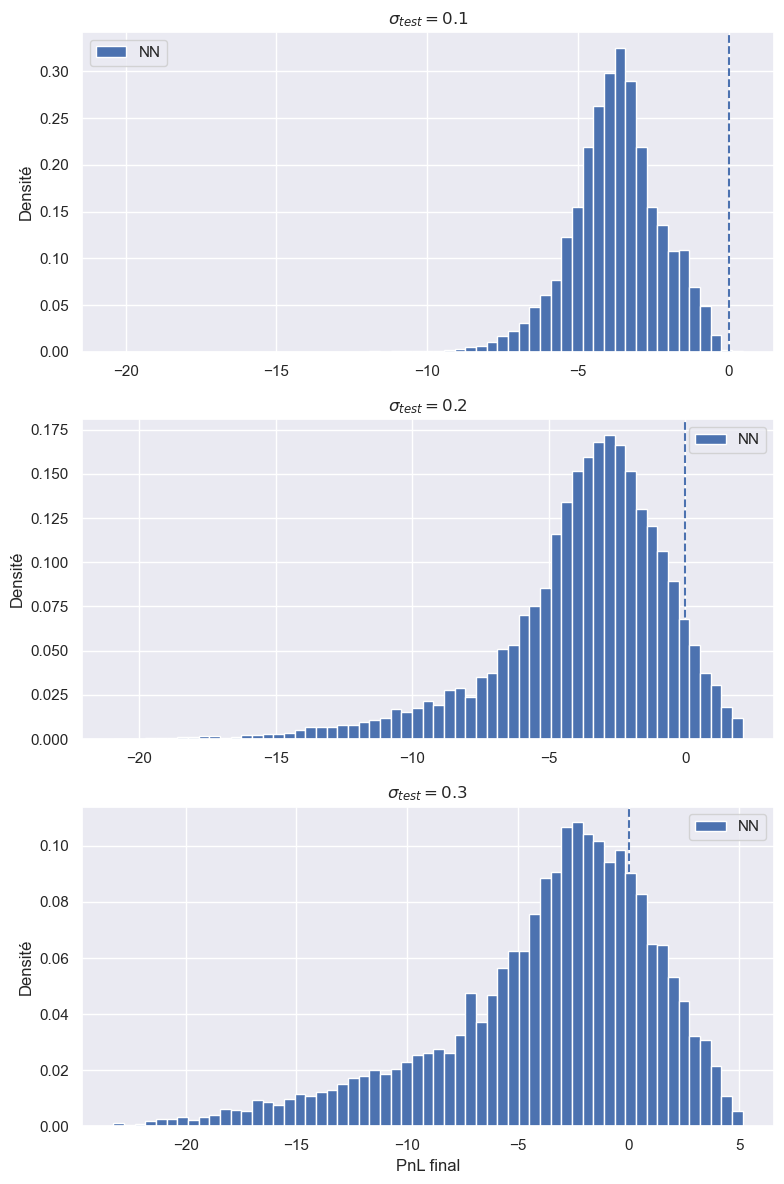

In [122]:
fig, axes = plt.subplots(
    len(sigma_test_range),
    1,
    figsize=(8, 4 * len(sigma_test_range))
)

if len(sigma_test_range) == 1:
    axes = [axes]

for ax, sigma_test in zip(axes, sigma_test_range):

    pnl_nn = pnl_by_sigma[sigma_test]["NN"]

    all_pnl = np.concatenate([pnl_nn, pnl_bs])

    bins = np.linspace(
        np.quantile(all_pnl, 0.001),
        np.quantile(all_pnl, 0.999),
        60
    )

    ax.hist(pnl_nn, bins=bins, density=True, label="NN")

    ax.axvline(0, linestyle="--")
    ax.set_title(rf"$\sigma_{{test}} = {sigma_test}$")
    ax.set_ylabel("Densité")
    ax.legend()

axes[-1].set_xlabel("PnL final")

plt.tight_layout()
plt.show()

Strike

In [123]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

K = 100
K_train = K
K_test_range = [80, 100, 120]
sigma = 0.20

eps = 5e-2
H = 32
M_test = 10**4
M = 10**6

results = []
pnl_by_K = {}


sample_S_raw = simulation_actif(N, T, M, S0, sigma, r)

times = np.arange(N + 1) * T / N

moyenne = S0 * np.exp(r * times)
ecart_type = S0 * np.exp(r * times) * np.sqrt(np.exp(sigma**2 * times) - 1)
ecart_type[0] = 1.0

sample_S_norm = (sample_S_raw - moyenne) / ecart_type

S_act = sample_S_raw * np.exp(-r * times)
dS_np = np.diff(S_act, axis=1)

tau_grid = (T - times[:-1]) / T

data_np = np.stack([
    sample_S_norm[:, :-1],
    np.repeat(tau_grid.reshape(1, -1), M, axis=0)
], axis=2)

phi_np = payoff_put(sample_S_raw[:, -1], K_train) * np.exp(-r * T)

data = torch.from_numpy(data_np).float().to(device)
dS_torch = torch.from_numpy(dS_np).float().to(device)
phi = torch.from_numpy(phi_np).float().to(device)
S_act_torch = torch.from_numpy(S_act).float().to(device)

P0_val = float(price_put_BS(S0, T, r, sigma, K_train))
P0 = torch.tensor(P0_val, dtype=torch.float32, device=device)

model = NeuralNetwork(input_size=3, hidden_size=H, output_size=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

size_tot = data.shape[0]
nb_batch = size_tot // batch_size

for epoch in range(n_epochs):

    perm = torch.randperm(size_tot, device=device)
    epoch_loss = 0.0

    for j in range(nb_batch):

        idx = perm[j * batch_size:(j + 1) * batch_size]

        X_batch = data[idx]
        dS_batch = dS_torch[idx]
        phi_batch = phi[idx]
        S_batch = S_act_torch[idx]

        batch_n = X_batch.shape[0]

        delta_prev = torch.zeros(batch_n, device=device)
        q_list = []

        for t in range(N):
            S_t = X_batch[:, t, 0]
            tau_t = X_batch[:, t, 1]

            input_t = torch.stack([S_t, tau_t, delta_prev], dim=1)
            delta_t = model(input_t).squeeze(-1)

            q_list.append(delta_t)
            delta_prev = delta_t

        q = torch.stack(q_list, dim=1)

        delta_pnl = (q * dS_batch).sum(dim=1)

        q_prev = torch.cat([torch.zeros(batch_n, 1, device=device), q], dim=1)
        q_next = torch.cat([q, torch.zeros(batch_n, 1, device=device)], dim=1)

        costs = eps * torch.sum(S_batch * torch.abs(q_next - q_prev), dim=1)

        pnl = P0 - phi_batch + delta_pnl - costs
        loss = torch.mean(pnl**2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= nb_batch
    print(f"Epoch {epoch+1}/{n_epochs} | Train MSE = {epoch_loss:.6f}")

model.eval()

np.random.seed(42)
sample_S_test = simulation_actif(N, T, M_test, S0, sigma, r)

sample_norm_test = (sample_S_test - moyenne) / ecart_type

tau_mat = np.repeat(tau_grid.reshape(1, -1), M_test, axis=0)

sample_S_test_disc = sample_S_test * np.exp(-r * times)
dS_test = np.diff(sample_S_test_disc, axis=1)

for K_test in K_test_range:

    print(f"\n===== TEST K = {K_test} =====")

    P0_test_val = float(price_put_BS(S0, T, r, sigma, K_test))

    payoff_disc = np.exp(-r * T) * np.maximum(K_test - sample_S_test[:, -1], 0)

    delta_prev = np.zeros(M_test)
    q_list = []

    with torch.no_grad():
        for t in range(N):
            S_t = sample_norm_test[:, t]
            tau_t = tau_mat[:, t]

            X_input = np.stack([S_t, tau_t, delta_prev], axis=1)
            X_input = torch.from_numpy(X_input).float().to(device)

            delta_t = model(X_input).squeeze(-1).cpu().numpy()

            q_list.append(delta_t)
            delta_prev = delta_t

    q_nn = np.stack(q_list, axis=1)

    q_prev_nn = np.concatenate([np.zeros((M_test, 1)), q_nn], axis=1)
    q_next_nn = np.concatenate([q_nn, np.zeros((M_test, 1))], axis=1)

    costs_nn = eps * np.sum(
        sample_S_test_disc * np.abs(q_next_nn - q_prev_nn),
        axis=1
    )

    pnl_nn = (
        P0_test_val
        - payoff_disc
        + np.sum(q_nn * dS_test, axis=1)
        - costs_nn
    )

    pnl_by_K[K_test] = {
    "NN": pnl_nn
}

    results.append({
        "K_test": K_test,
        "NN_MSE": np.mean(pnl_nn**2),
        "NN_Mean": np.mean(pnl_nn),
        "NN_Std": np.std(pnl_nn),
        "NN_Q01": np.quantile(pnl_nn, 0.01),
        "NN_Q99": np.quantile(pnl_nn, 0.99),
        "NN_Mean_cost": np.mean(costs_nn),
    })

results_df = pd.DataFrame(results)
print(results_df.round(6))

Epoch 1/10 | Train MSE = 23.537331
Epoch 2/10 | Train MSE = 22.384586
Epoch 3/10 | Train MSE = 22.215874
Epoch 4/10 | Train MSE = 22.084487
Epoch 5/10 | Train MSE = 22.015736
Epoch 6/10 | Train MSE = 21.971649
Epoch 7/10 | Train MSE = 21.944462
Epoch 8/10 | Train MSE = 21.916290
Epoch 9/10 | Train MSE = 21.900885
Epoch 10/10 | Train MSE = 21.891665

===== TEST K = 80 =====

===== TEST K = 100 =====

===== TEST K = 120 =====
   K_test      NN_MSE   NN_Mean    NN_Std     NN_Q01    NN_Q99  NN_Mean_cost
0      80   20.995970 -2.898835  3.548623  -9.120911  5.135988      2.914883
1     100   22.369425 -2.985154  3.668553 -15.999986  2.048997      2.914883
2     120  100.261054 -2.933400  9.573725 -24.561448  9.279217      2.914883


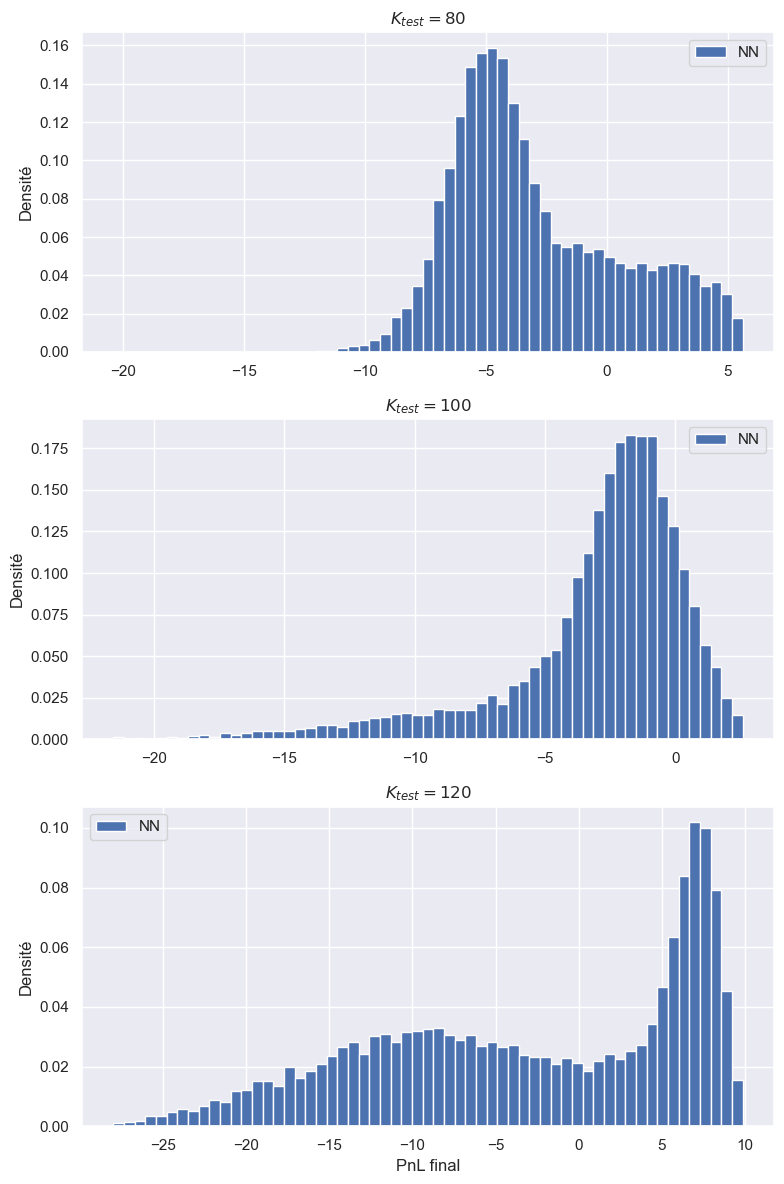

In [124]:
fig, axes = plt.subplots(
    len(K_test_range),
    1,
    figsize=(8, 4 * len(K_test_range)),
    sharex=False
)

if len(K_test_range) == 1:
    axes = [axes]

for ax, K_test in zip(axes, K_test_range):

    pnl_nn = pnl_by_K[K_test]["NN"]

    all_pnl = np.concatenate([pnl_nn, pnl_bs])

    bins = np.linspace(
        np.quantile(all_pnl, 0.001),
        np.quantile(all_pnl, 0.999),
        60
    )

    ax.hist(pnl_nn, bins=bins, density=True, label="NN")

    ax.set_title(rf"$K_{{test}} = {K_test}$")
    ax.set_ylabel("Densité")
    ax.legend()

axes[-1].set_xlabel("PnL final")

plt.tight_layout()
plt.show()